# Projet de Statistique : Analyse du Jeu de Données meteoSDD

# Auteurs
DUSOLLIER Baptiste ; GERARD François ; SECHET Edouard ; GUILLARME Côme ; GUEDJ Alexandre ; HOUSSENALY Ali

## Partie 1 : Présentation et analyse exploratoire des données

### Import et aperçu

In [1]:
# Installation des packages si nécessaire
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("patchwork")) install.packages("patchwork")
if (!require("ggcorrplot")) install.packages("ggcorrplot")
if (!require("dplyr")) install.packages("dplyr")
if (!require("pls")) install.packages("pls")
if (!require("maps")) install.packages("maps")

# Chargement des packages
library(maps)
library(ggplot2)
library(patchwork)
library(rlang)
library(ggcorrplot)
library(dplyr)
library(pls)

Loading required package: ggplot2

Loading required package: patchwork

Loading required package: ggcorrplot

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: pls


Attaching package: ‘pls’


The following object is masked from ‘package:stats’:

    loadings


Loading required package: maps



In [2]:
# Lecture du fichier CSV
data <- read.csv("donnees-synop-essentielles-omm.csv", sep = ";")

In [3]:
# Aperçu des premières lignes
head(data)

# Dimensions du jeu de données
cat("Dimensions du jeu de données :", dim(data)[1], "lignes et", dim(data)[2], "colonnes\n")

# Noms des colonnes
cat("Noms des colonnes :", names(data), "\n")

,ID.OMM.station,Date,Pression.au.niveau.mer,Variation.de.pression.en.3.heures,Type.de.tendance.barométrique,Direction.du.vent.moyen.10.mn,Vitesse.du.vent.moyen.10.mn,Température,Point.de.rosée,Humidité,⋯,Altitude,communes..name.,communes..code.,EPCI..name.,EPCI..code.,department..name.,department..code.,region..name.,region..code.,mois_de_l_annee
,<int>,<chr>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,⋯,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>
1,7690,2017-04-05T11:00:00+02:00,101580,100,2,90,1.3,289.95,285.25,74,⋯,2,Nice,06088,Métropole Nice Côte d'Azur,200030195,Alpes-Maritimes,06,Provence-Alpes-Côte d'Azur,93,4
2,61998,2017-04-05T11:00:00+02:00,102720,-200,8,320,20.1,285.65,281.95,78,⋯,29,,,,NA,,,,NA,4
3,78925,2018-04-04T05:00:00+02:00,101420,60,1,100,3.6,298.45,295.15,82,⋯,3,Le Lamentin,97213,CA du Centre de la Martinique,249720061,Martinique,972,Martinique,2,4
4,61998,2018-04-05T05:00:00+02:00,101190,40,1,290,5.1,278.15,272.75,68,⋯,29,,,,NA,,,,NA,4
5,7690,2018-04-05T08:00:00+02:00,101240,-20,5,320,1.6,284.25,280.15,76,⋯,2,Nice,06088,Métropole Nice Côte d'Azur,200030195,Alpes-Maritimes,06,Provence-Alpes-Côte d'Azur,93,4
6,7149,2018-04-08T05:00:00+02:00,100730,-20,5,30,2.3,285.55,283.25,86,⋯,89,Athis-Mons,91027,Métropole du Grand Paris,200054781,Essonne,91,Île-de-France,11,4


Dimensions du jeu de données : 1719567 lignes et 82 colonnes
Noms des colonnes : ID.OMM.station Date Pression.au.niveau.mer Variation.de.pression.en.3.heures Type.de.tendance.barométrique Direction.du.vent.moyen.10.mn Vitesse.du.vent.moyen.10.mn Température Point.de.rosée Humidité Visibilité.horizontale Temps.présent Temps.passé.1 Temps.passé.2 Nebulosité.totale Nébulosité..des.nuages.de.l..étage.inférieur Hauteur.de.la.base.des.nuages.de.l.étage.inférieur Type.des.nuages.de.l.étage.inférieur Type.des.nuages.de.l.étage.moyen Type.des.nuages.de.l.étage.supérieur Pression.station Niveau.barométrique Géopotentiel Variation.de.pression.en.24.heures Température.minimale.sur.12.heures Température.minimale.sur.24.heures Température.maximale.sur.12.heures Température.maximale.sur.24.heures Température.minimale.du.sol.sur.12.heures Méthode.de.mesure.Température.du.thermomètre.mouillé Température.du.thermomètre.mouillé Rafale.sur.les.10.dernières.minutes Rafales.sur.une.période Periode.de.mesure

### Visualisation des données manquantes

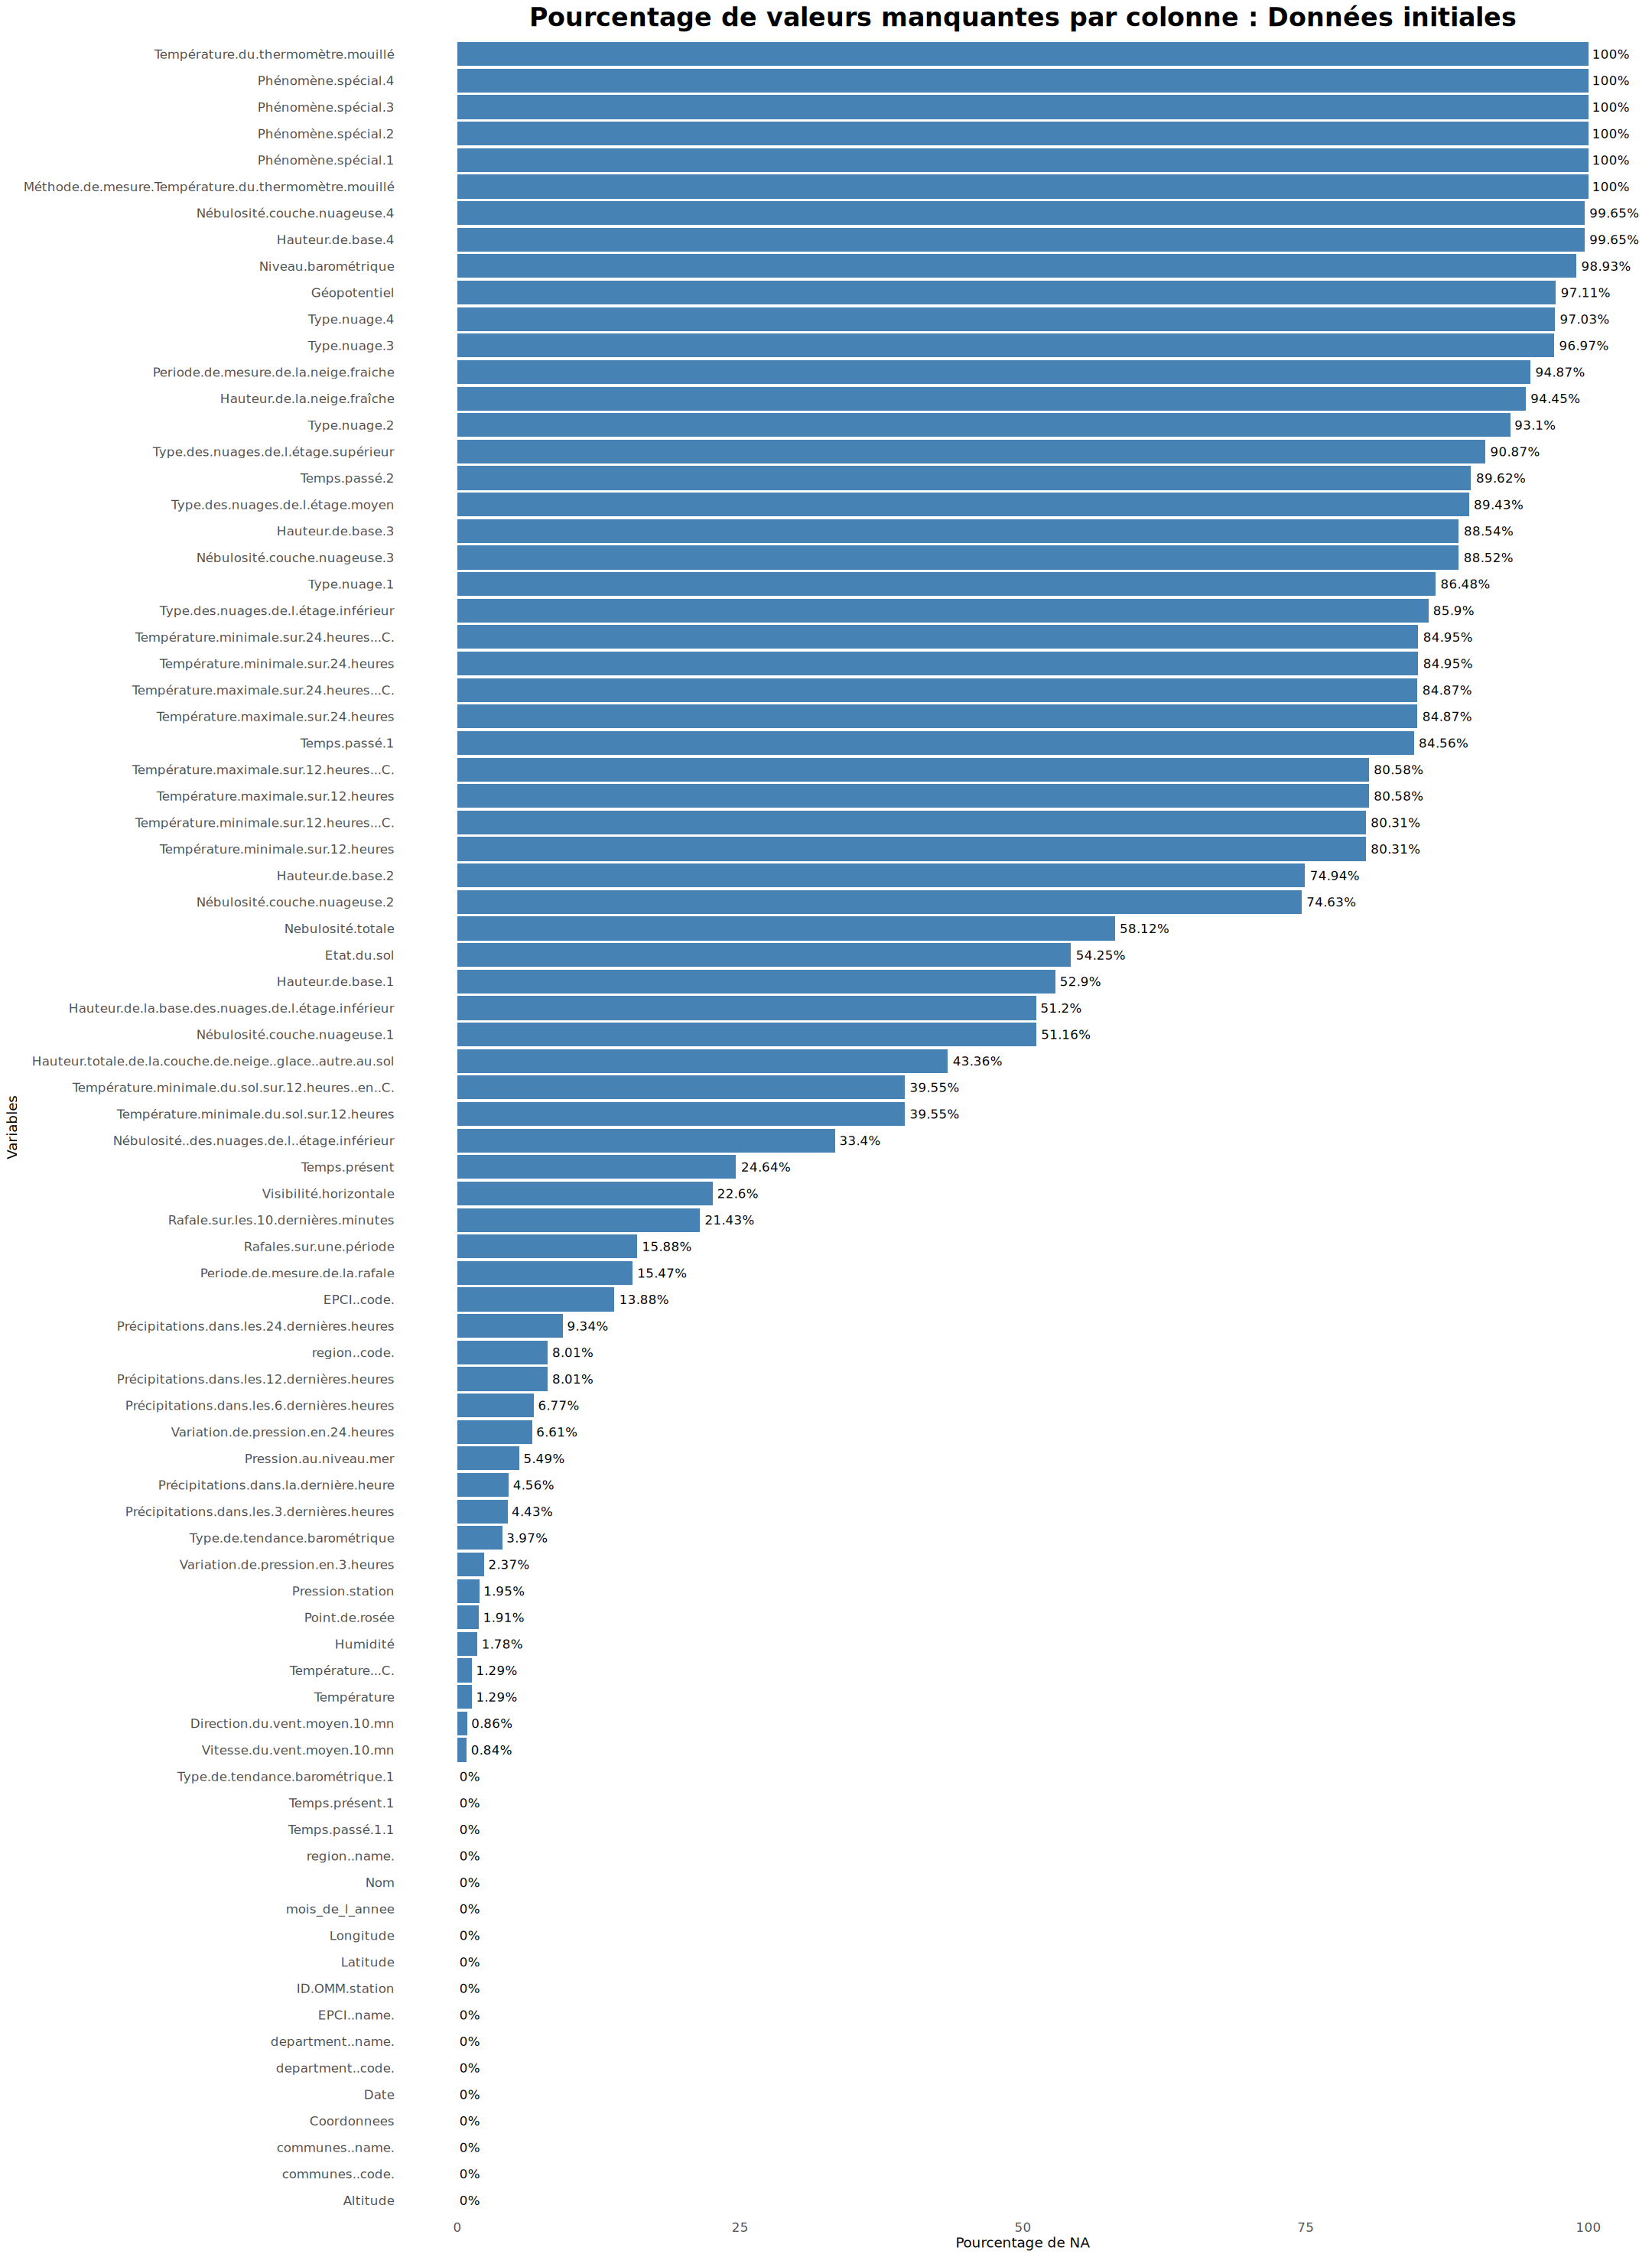

In [4]:
# Taille du graphique
options(repr.plot.width = 18, repr.plot.height = max(6, 0.3 * ncol(data)))

# Calcul du pourcentage de NA
na_percent <- sapply(data, function(x) mean(is.na(x)) * 100)
na_df <- data.frame(Variable = names(na_percent), NA_Percent = round(na_percent, 2))
na_df <- na_df[order(na_df$NA_Percent, decreasing = TRUE), ]

# Graphique
ggplot(na_df, aes(x = reorder(Variable, NA_Percent), y = NA_Percent)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = paste0(NA_Percent, "%")), hjust = -0.1, size = 3.5) +
  coord_flip() +
  labs(title = "Pourcentage de valeurs manquantes par colonne : Données initiales",
       x = "Variables",
       y = "Pourcentage de NA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(size = 10),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

### Méthodologie d'approche du jeu de données

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 -33.50    8.80   15.00   15.41   23.50   59.70   22176 

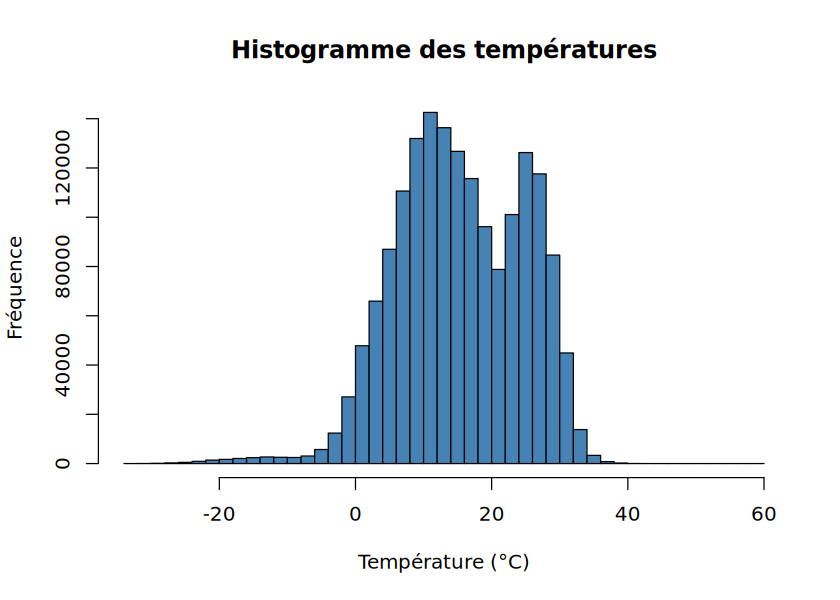

In [5]:
# Statistiques de base sur la température
summary(data$Température...C.)

# Taille du graphique
options(repr.plot.width = 7, repr.plot.height = 5)

# Histogramme des températures
hist(data$Température...C., 
     breaks = 50,  # Définit le nombre de barres
     main = "Histogramme des températures", 
     xlab = "Température (°C)", 
     ylab = "Fréquence",
     col = "steelblue", 
     border = "black")

Sur la base des graphes ci-dessus, tout au long de ce projet, nous prendrons comme indicateur cible **la température**. En effet :

- Elle est continue (elle peut prendre toute les valeurs dans l'intervalle : $[-33°C, 60°C]$), assez bien distribuée (on observe une répartition approximativement normale sur l'intervalle $[-5°C, 40°C]$), et présente dans presque toutes les lignes (seulement 1.29% des lignes sont vides pour cette variable)

- Elle est physiquement influencée par de nombreuses autres variables : pression, humidité, vent, précipitations, etc.

- Elle est interprétable : facile à relier à des phénomènes météo ou géographiques

- Elle est utile pour toutes les étapes suivantes :
    - Estimateurs : moyenne, variance, biais
    - Tests : comparaison entre régions ou saisons
    - Régression : prédiction à partir d'autres variables
    - ACP/PLS : réduction de dimension autour de la température
    - Clustering : regroupement de stations ou de jours selon profils thermique


Ainsi, pour rendre ce jeu de données plus digeste et sélectionner les éléments dont nous aurons besoin, nous allons prendre plusieurs décisions :

- Toutes les colonnes avec plus de 50 % de données manquantes sont retirées de notre analyse.

- Cette première décision supprime une grande partie des variables concernant la neige. En effet, ces variables ont beaucoup de valeurs manquantes puisqu’il ne neige pas tout au long de l’année. Au vu de cette décision, il est préférable de ne pas considérer la neige dans nos analyses et de supprimer toutes les colonnes restantes la concernant. Cela va nous permettre de simplifier un peu plus le dataset.

- Les colonnes de températures sélectionnées seront les colonnes en degré Celsius pour simplifier l’interprétation. En effet, les colonnes de température sont présentes en Kelvin et en degré Celsius ; il est inutile de conserver les deux.

Ces choix ne visent pas à appauvrir le jeu de données, mais à le rendre plus robuste et cohérent pour l’application des méthodes statistiques vues en cours. Ils permettent de concentrer l’analyse sur des variables fiables, interprétables et comparables.


### Nettoyage du jeu de données

In [6]:
# 1. Supprimer les colonnes avec plus de 50% de NA
na_threshold <- 0.5
na_percent <- sapply(data, function(x) mean(is.na(x)))
data_final <- data[, na_percent <= na_threshold]

# 2. Supprimer la colonne restante liée à la neige
data_final <- data_final[, !grepl("Hauteur.totale.de.la.couche.de.neige..glace..autre.au.sol", names(data_final))]

# 3. Conserver uniquement les colonnes de température en °C
data_final <- data_final[, !(names(data_final) %in% c("Température.minimale.du.sol.sur.12.heures", "Température"))]

Noms des colonnes : ID.OMM.station Date Pression.au.niveau.mer Variation.de.pression.en.3.heures Type.de.tendance.barométrique Direction.du.vent.moyen.10.mn Vitesse.du.vent.moyen.10.mn Point.de.rosée Humidité Visibilité.horizontale Temps.présent Nébulosité..des.nuages.de.l..étage.inférieur Pression.station Variation.de.pression.en.24.heures Rafale.sur.les.10.dernières.minutes Rafales.sur.une.période Periode.de.mesure.de.la.rafale Précipitations.dans.la.dernière.heure Précipitations.dans.les.3.dernières.heures Précipitations.dans.les.6.dernières.heures Précipitations.dans.les.12.dernières.heures Précipitations.dans.les.24.dernières.heures Coordonnees Nom Type.de.tendance.barométrique.1 Temps.passé.1.1 Temps.présent.1 Température...C. Température.minimale.du.sol.sur.12.heures..en..C. Latitude Longitude Altitude communes..name. communes..code. EPCI..name. EPCI..code. department..name. department..code. region..name. region..code. mois_de_l_annee 


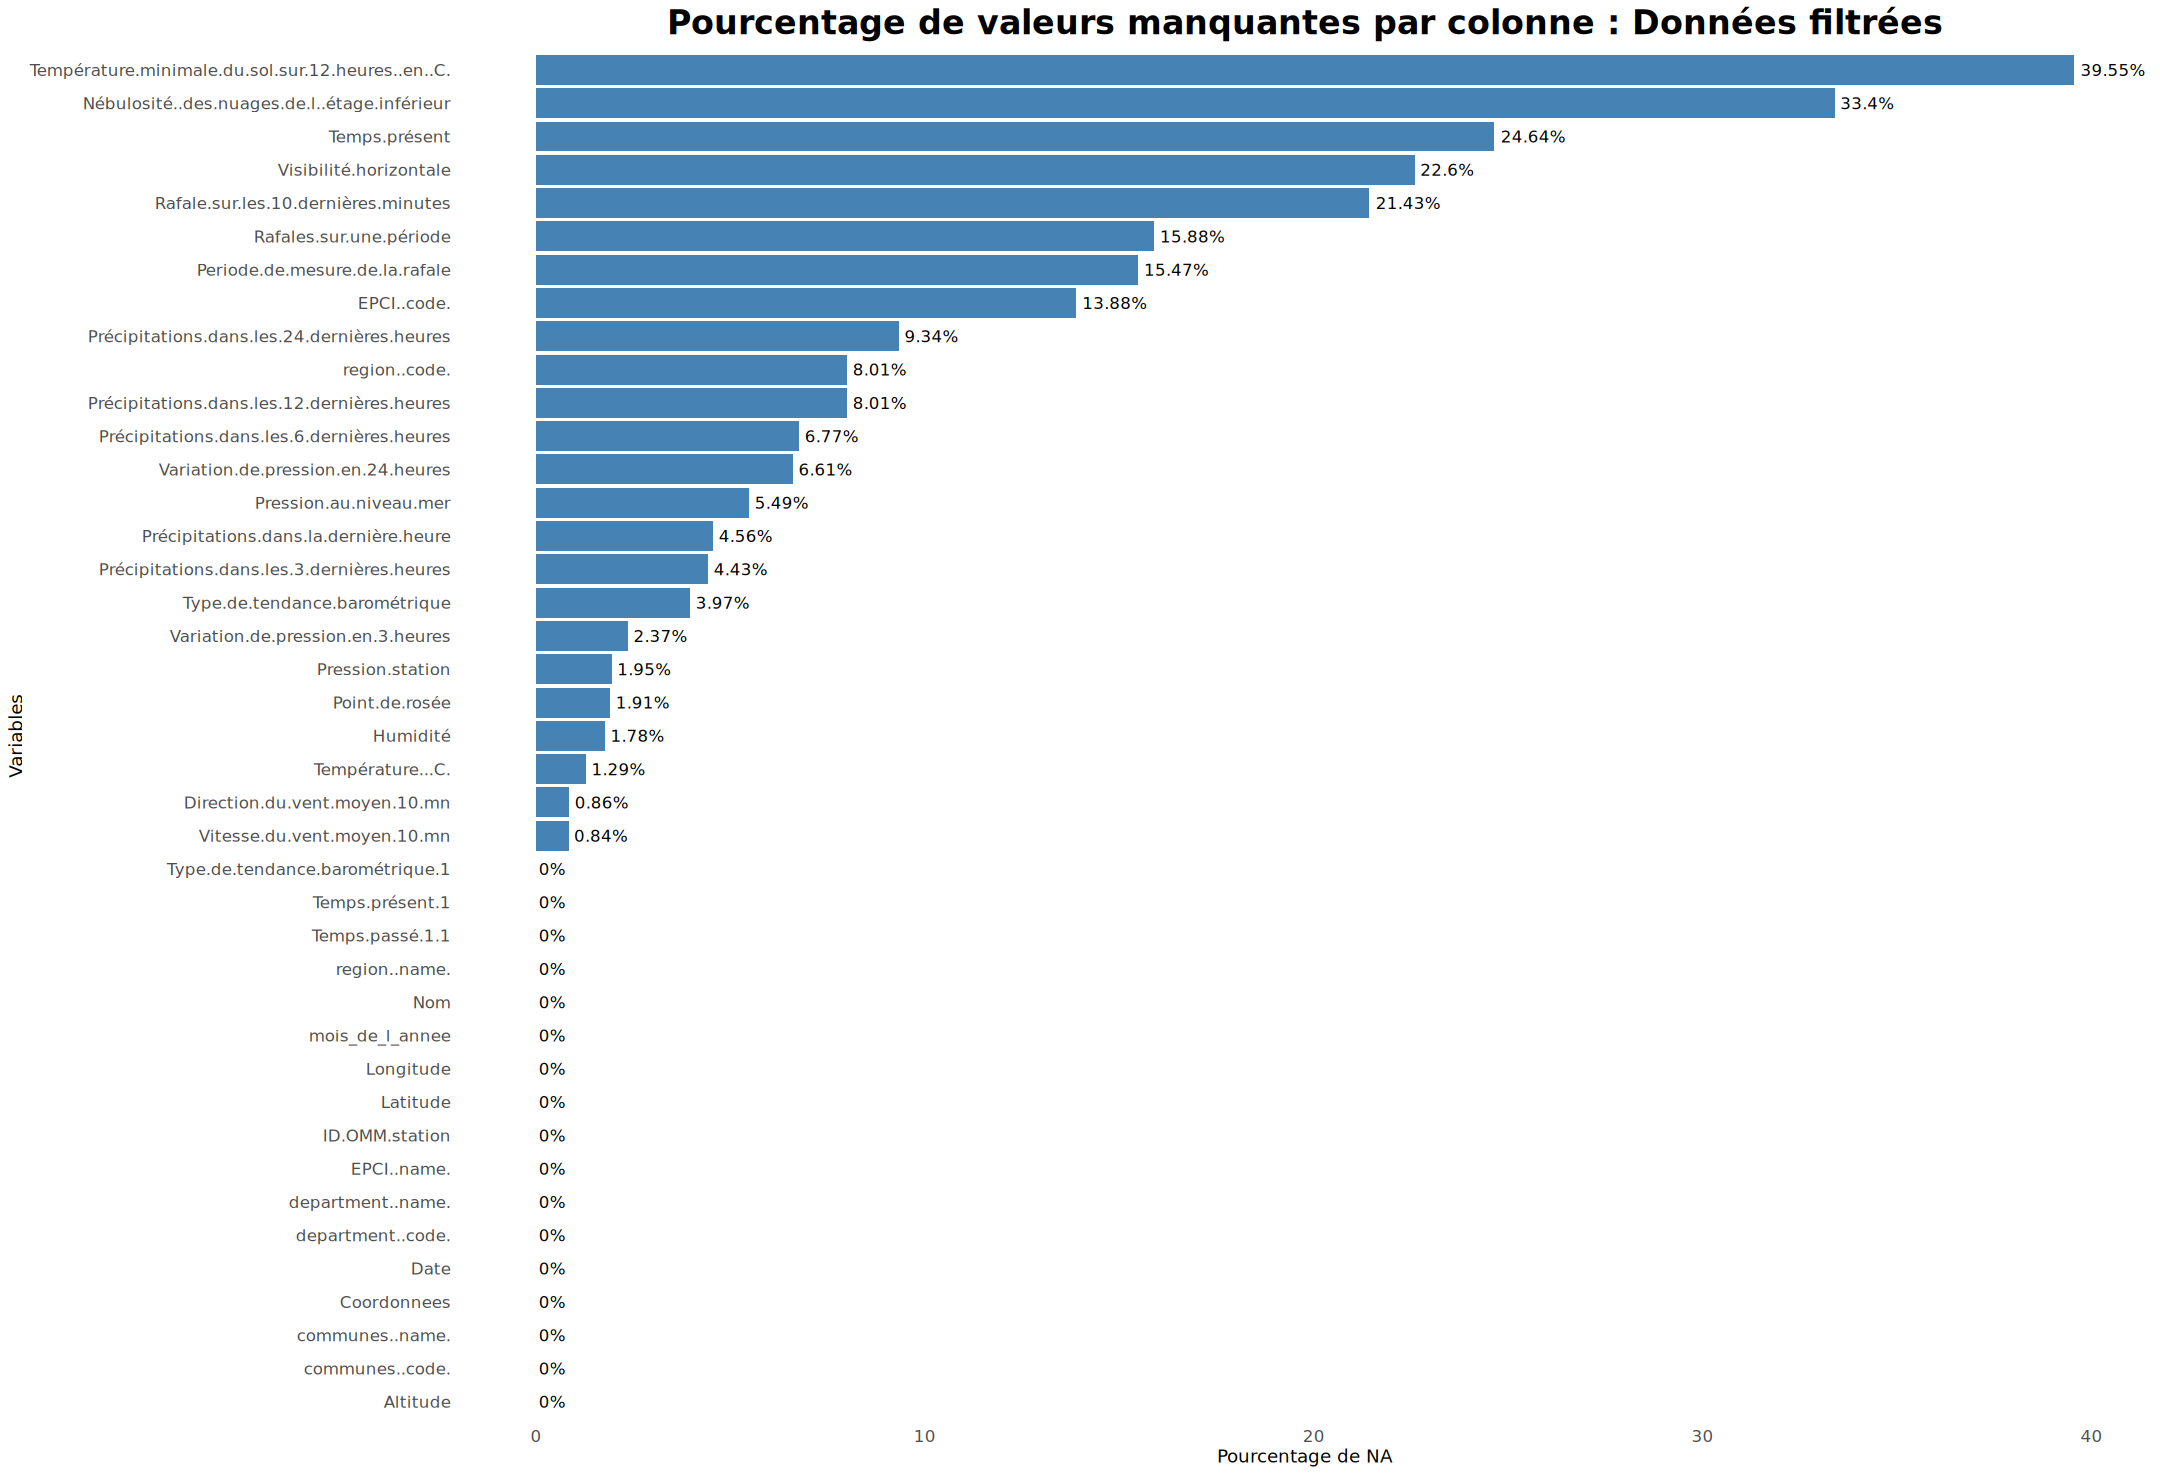

In [7]:
# Taille du graphique
options(repr.plot.width = 18, repr.plot.height = max(6, 0.3 * ncol(data_final)))

# Calcul du pourcentage de NA
na_percent <- sapply(data_final, function(x) mean(is.na(x)) * 100)
na_df <- data.frame(Variable = names(na_percent), NA_Percent = round(na_percent, 2))
na_df <- na_df[order(na_df$NA_Percent, decreasing = TRUE), ]

# Graphique
ggplot(na_df, aes(x = reorder(Variable, NA_Percent), y = NA_Percent)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  geom_text(aes(label = paste0(NA_Percent, "%")), hjust = -0.1, size = 3.5) +
  coord_flip() +
  labs(title = "Pourcentage de valeurs manquantes par colonne : Données filtrées",
       x = "Variables",
       y = "Pourcentage de NA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.text.x = element_text(size = 10),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

cat("Noms des colonnes :", names(data_final), "\n")

### Analyse des données

#### Statistiques de base des valeurs numériques de data_final

In [8]:
# Sélection des colonnes numériques
numeric_data <- data_final[sapply(data_final, is.numeric)]

# Largeurs fixes
name_width <- 55
value_width <- 15

# En-tête
cat(sprintf("%-*s | %*s | %*s | %*s | %*s\n",
            name_width, "Variable",
            value_width, "Min",
            value_width, "Max",
            value_width, "Mean",
            value_width, "SD"))
cat(strrep("-", name_width + 15 + value_width * 4), "\n")

# Boucle d'affichage
for (colname in names(numeric_data)) {
  col <- numeric_data[[colname]]
  min_val <- round(min(col, na.rm = TRUE), 2)
  max_val <- round(max(col, na.rm = TRUE), 2)
  mean_val <- round(mean(col, na.rm = TRUE), 2)
  sd_val <- round(sd(col, na.rm = TRUE), 2)
  
  cat(sprintf("%-*s | %*.2f | %*.2f | %*.2f | %*.2f\n",
              name_width, colname,
              value_width, min_val,
              value_width, max_val,
              value_width, mean_val,
              value_width, sd_val))
}

Variable                                                |             Min |             Max |            Mean |              SD


---------------------------------------------------------------------------------------------------------------------------------- 
ID.OMM.station                                          |         7005.00 |        89642.00 |        26062.16 |        29911.14
Pression.au.niveau.mer                                  |        93850.00 |       107570.00 |       101576.62 |          913.15
Variation.de.pression.en.3.heures                       |        -2840.00 |         2990.00 |           15.39 |          126.79
Type.de.tendance.barométrique                          |            0.00 |           10.00 |            4.30 |            2.72
Direction.du.vent.moyen.10.mn                           |            0.00 |          360.00 |          175.63 |          104.55
Vitesse.du.vent.moyen.10.mn                             |            0.00 |           47.20 |            4.15 |            3.19
Point.de.rosée                                         |          223.95 |          332.45 |         

#### Visualisation de toutes les colonnes numériques : Scatter plot de la température en fonction des colonnes numériques et Matrice de corrélation

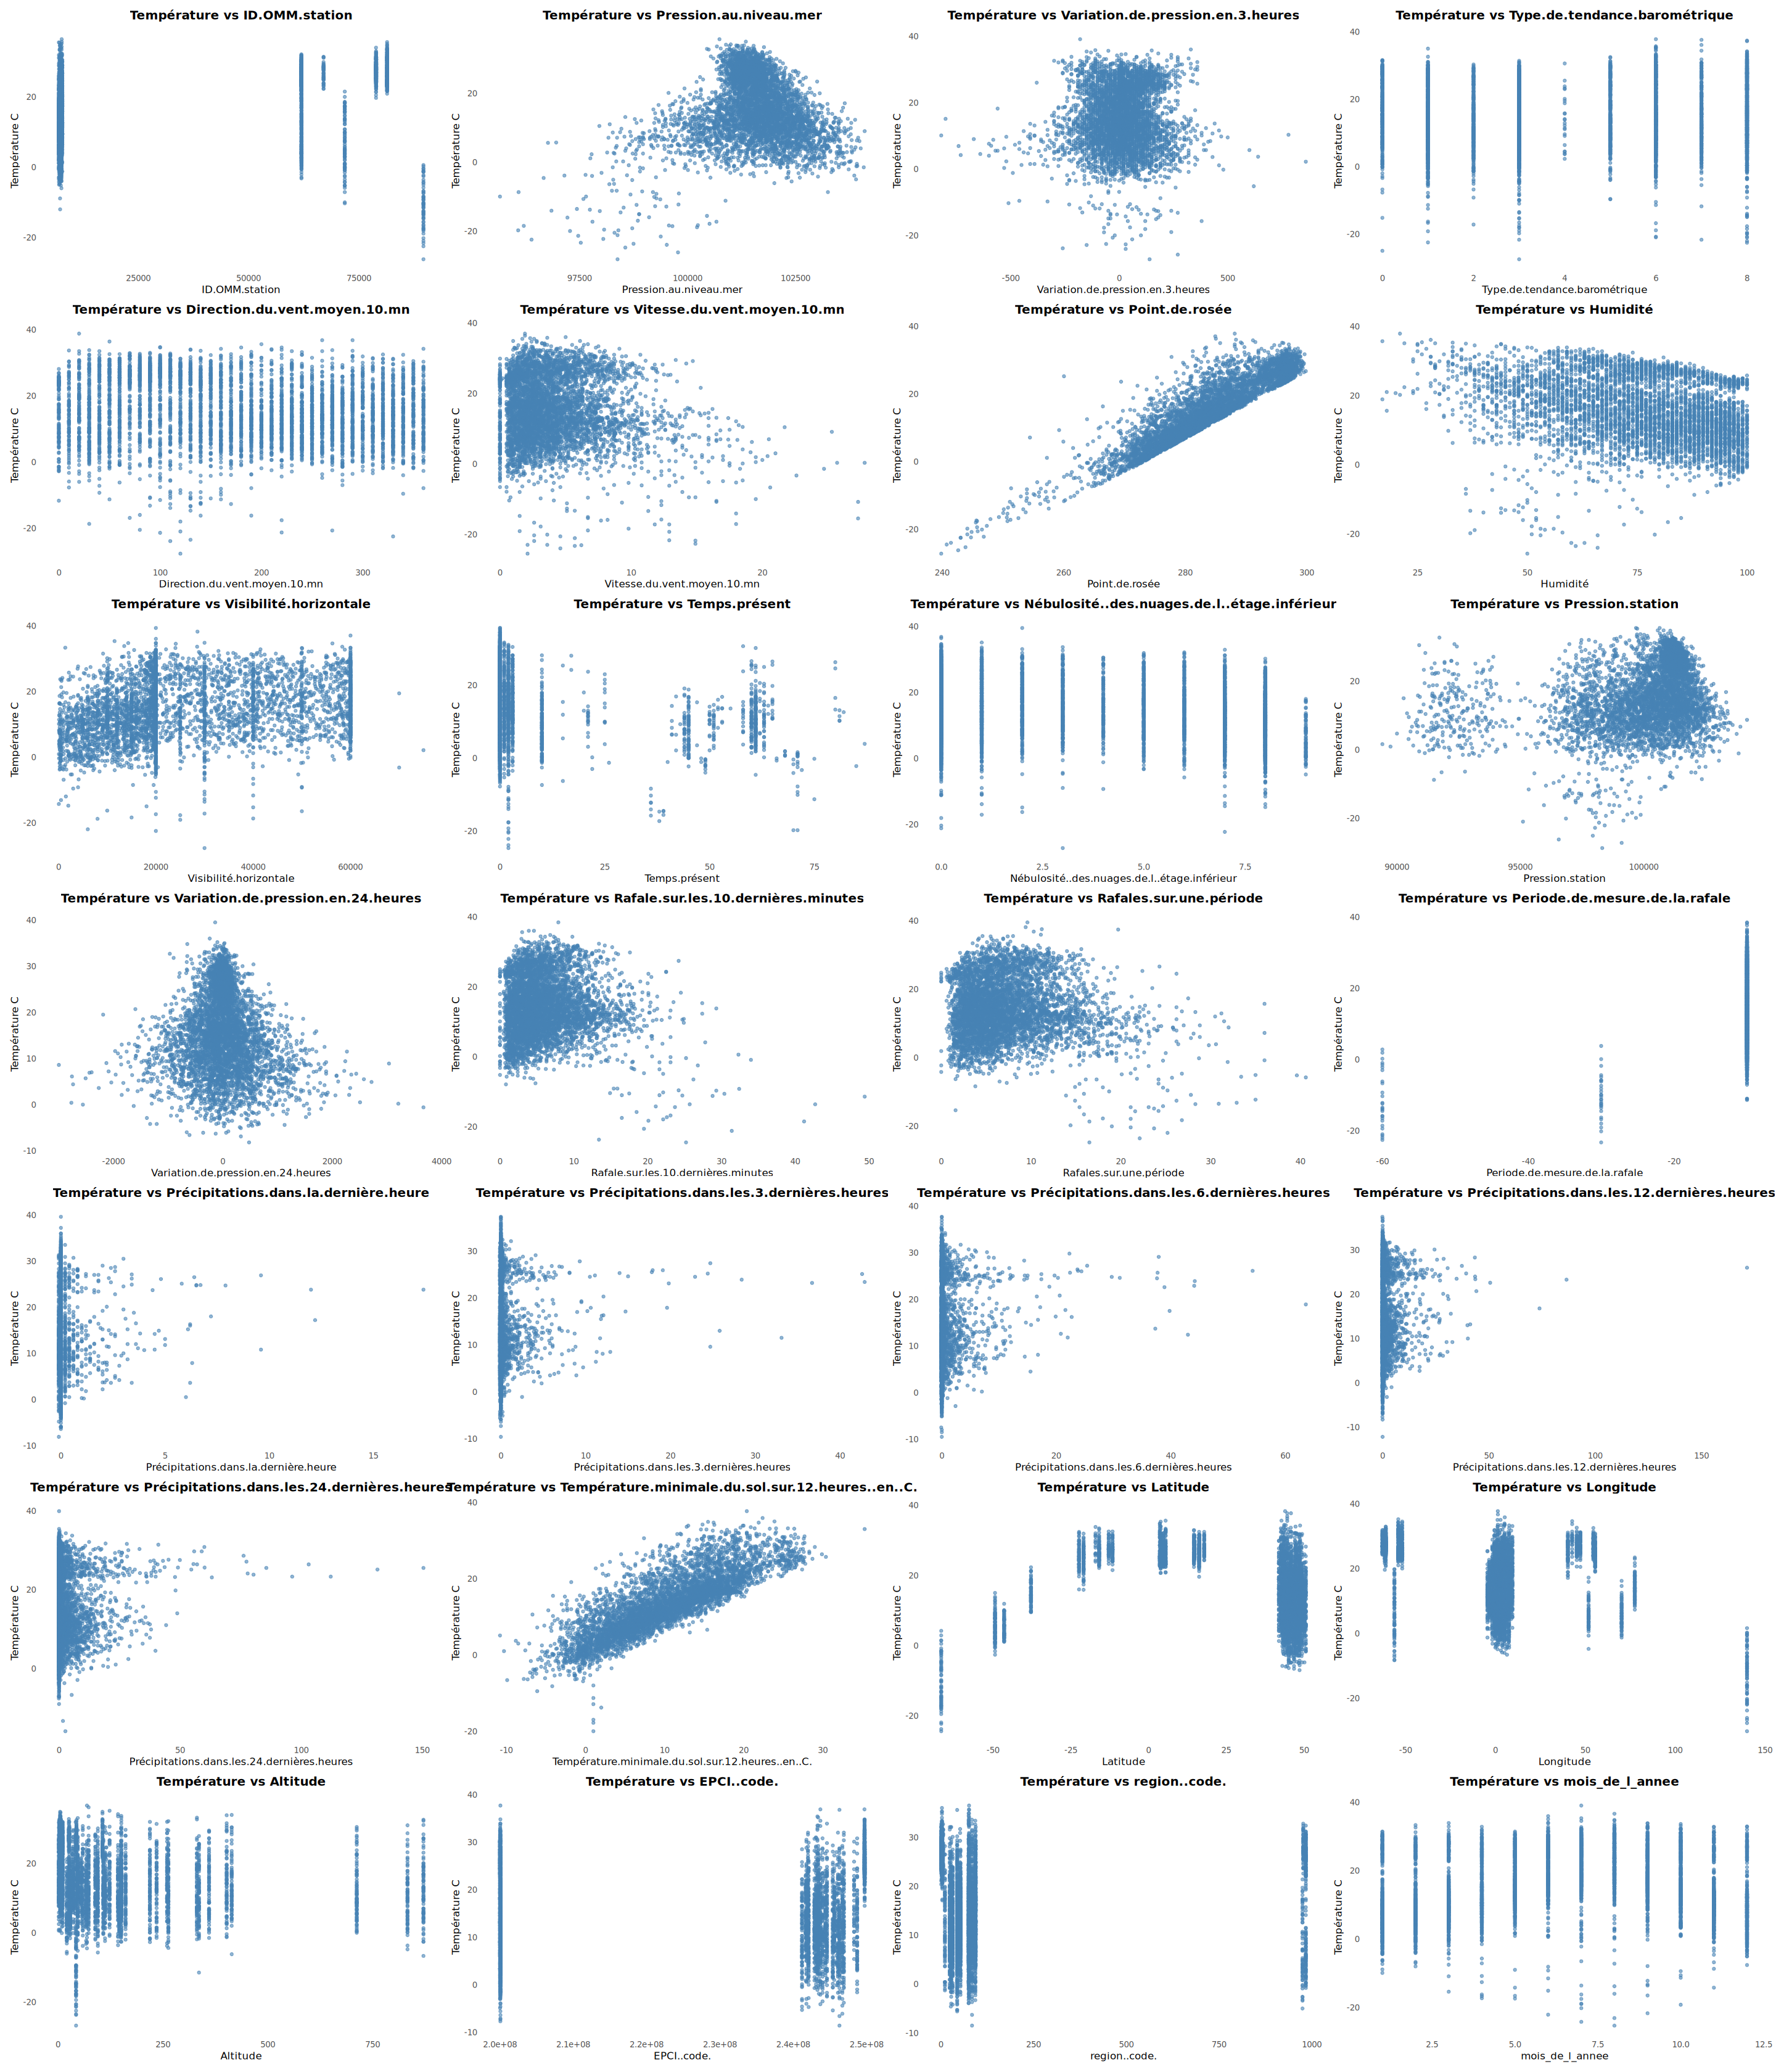

In [9]:
# Paramètres
num_col <- 4 # Nombre de colonnes dans la grille
max_points <- 5000  # Nombre max de points par plot pour éviter la surcharge

# Variable cible
target_var <- "Température...C."

# Sélection des variables numériques (hors cible)
numeric_vars <- names(data_final)[sapply(data_final, is.numeric)]
numeric_vars <- setdiff(numeric_vars, target_var)

# Construire les plots avec sous-échantillonnage en éliminant les NAs
plot_list <- lapply(numeric_vars, function(var) {
  df_clean <- data_final[!is.na(data_final[[var]]) & !is.na(data_final[[target_var]]), ]

  # Sous-échantillonnage
  if (nrow(df_clean) > max_points) {
    df_clean <- df_clean[sample(nrow(df_clean), max_points), ]
  }
  
  ggplot(df_clean, aes(x = .data[[var]], y = .data[[target_var]])) +
    geom_point(color = "steelblue", alpha = 0.6, size = 1.2) +
    labs(title = paste("Température vs", var),
         x = var,
         y = gsub("\\.+", " ", target_var)) +
    theme_minimal(base_size = 10) +
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
      panel.grid = element_blank()
    )
})

# Ajuster la taille du canevas
options(repr.plot.width = 6 * num_col,
        repr.plot.height = 4 * ceiling(length(plot_list) / num_col))

# Afficher la grille
wrap_plots(plotlist = plot_list, ncol = num_col)

# Réinitialiser la taille du canevas
options(repr.plot.width = 7, repr.plot.height = 5)


Warning message in cor(numeric_data, use = "complete.obs"):
“the standard deviation is zero”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the ggcorrplot package.
  Please report the issue at <https://github.com/kassambara/ggcorrplot/issues>.”


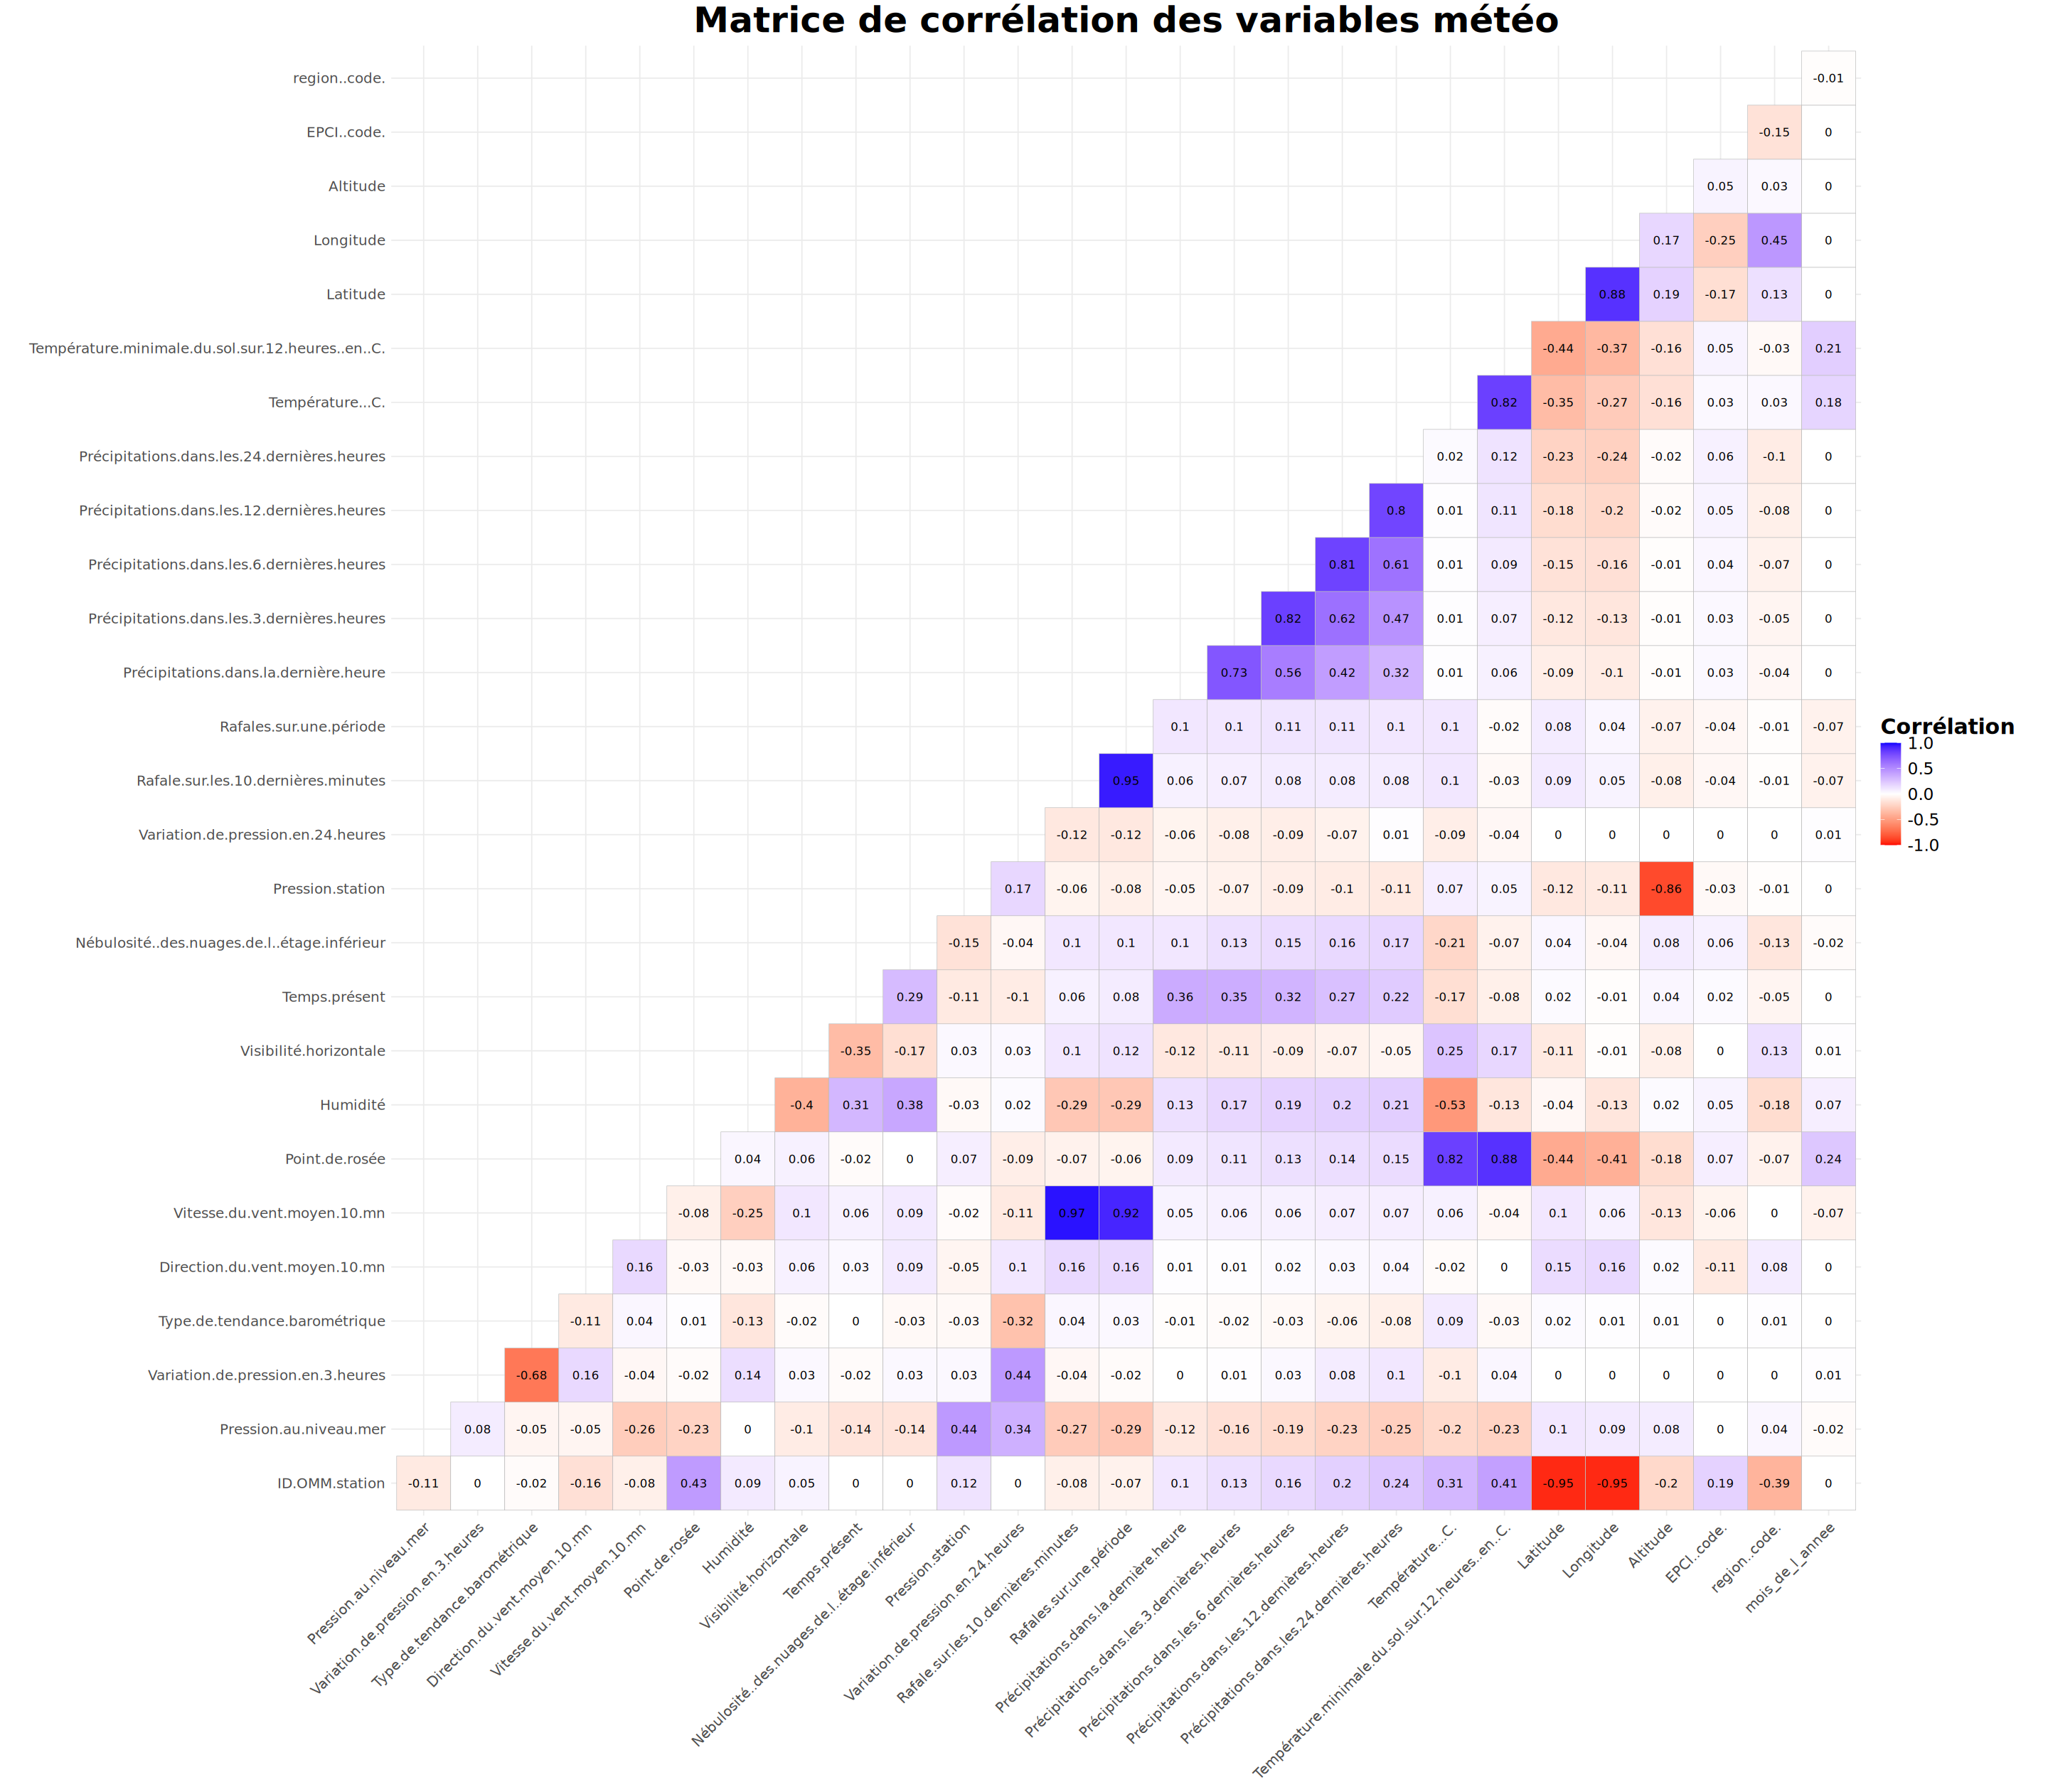

In [10]:
# Calculer la matrice de corrélation
cor_matrix <- cor(numeric_data, use = "complete.obs")

# Ajuster la taille du canevas
options(repr.plot.width = 6 * num_col,
        repr.plot.height = 3 * ceiling(length(plot_list) / num_col))

# Afficher la heatmap

ggcorrplot(cor_matrix,
           method = "square",          
           type = "lower",
           lab = TRUE,
           lab_size = 3.5,
           legend.title = "Corrélation",
           colors = c("red", "white", "blue"),
           title = "Matrice de corrélation des variables météo",
           ggtheme = theme_minimal() +
                     theme(
                       plot.title = element_text(hjust = 0.5, face = "bold", size = 30),
                       legend.title = element_text(size = 18, face = "bold"),
                       legend.text = element_text(size = 14)
                     )
)

# Réinitialiser la taille du canevas
options(repr.plot.width = 7, repr.plot.height = 5)


### Conclusion de l'analyse exploratoire

Nous avons choisi la température comme variable d’intérêt principal, ce qui nous a permis de recentrer l’analyse sur les colonnes les plus pertinentes du jeu de données. L’exploration statistique, à travers des indicateurs descriptifs, un scatter plot global et une matrice de corrélation, a mis en évidence des relations significatives entre les variables météorologiques. Ces visualisations vont faciliter l’interprétation des tendances et des interactions, ouvrant la voie à nos analyses suivantes.

## Partie 2 : calcul et étude d'estimateur

### Moyenne et intervalle de confiance (IC) à 95%

In [11]:
temp <- data$Température...C.[!is.na(data$Température...C.)]
n <- length(temp)
moyenne <- mean(temp)
ecart_type <- sd(temp)
erreur_standard <- ecart_type / sqrt(n)
IC_inf <- moyenne - 1.96 * erreur_standard
IC_sup <- moyenne + 1.96 * erreur_standard

cat(sprintf("Moyenne de la température : %.2f °C\n", moyenne))
cat(sprintf("Intervalle de confiance à 95%% : [%.2f ; %.2f] °C\n", IC_inf, IC_sup))


Moyenne de la température : 15.41 °C
Intervalle de confiance à 95% : [15.40 ; 15.42] °C


### Estimation par région

In [12]:
data_final %>%
  group_by(region..name.) %>%
  summarise(
    moyenne = mean(Température...C., na.rm = TRUE),
    IC_inf = moyenne - 1.96 * sd(Température...C., na.rm = TRUE)/sqrt(n()),
    IC_sup = moyenne + 1.96 * sd(Température...C., na.rm = TRUE)/sqrt(n())
  )

region..name.,moyenne,IC_inf,IC_sup
<chr>,<dbl>,<dbl>,<dbl>
,11.112798,11.037179,11.188417
Auvergne-Rhône-Alpes,12.843774,12.796536,12.891012
Bourgogne-Franche-Comté,12.254824,12.161499,12.348148
Bretagne,12.772030,12.741977,12.802083
Centre-Val de Loire,12.964214,12.903710,13.024717
Corse,16.817424,16.761716,16.873132
Grand Est,11.902154,11.861553,11.942756
Guadeloupe,26.896396,26.874872,26.917919
Guyane,26.486657,26.468090,26.505224


### Estimation BootStrap

On va faire une estimation avec la méthode BootStrap pour vérifier que la moyenne et l'écart type qu'on vient de calculer sont bons.

In [13]:
set.seed(123)  # Pour la reproductibilité
temp_sample <- sample(temp, size = 10000, replace = FALSE)  # Prendre 10 000 observations

# Fonction pour calculer la moyenne
boot_mean <- function(data, indices) {
  return(mean(data[indices]))
}

# Bootstrap (1000 réplicats)
library(boot)
results <- boot(temp_sample, boot_mean, R = 1000)
boot.ci(results, type = "bca")  # Intervalle de confiance


BOOTSTRAP CONFIDENCE INTERVAL CALCULATIONS
Based on 1000 bootstrap replicates

CALL : 
boot.ci(boot.out = results, type = "bca")

Intervals : 
Level       BCa          
95%   (15.26, 15.64 )  
Calculations and Intervals on Original Scale

La moyenne de température qu'on avait calculé (15.41) se trouve bien dans cet intervalle de confiance, on peut donc dire que notre estimateur est correct.

## Partie 3 : Tests statistiques

### I. Variabilité de la température en fonction des saisons

On souhaite tout d'abord comparer la température moyenne en fonction des saisons à l'aide d'un test statistique :

In [14]:
data_final$Mois <- as.numeric(format(as.Date(data_final$Date), "%m"))
data_final$Saison <- cut(data_final$Mois,
                         breaks = c(0, 2, 5, 8, 11, 12),
                         labels = c("Hiver", "Printemps", "Été", "Automne", "Hiver"),
                         right = TRUE)
data_final <- data_final[!is.na(data_final$Saison) & !is.na(data_final$Température...C.), ]
anova_result <- aov(Température...C. ~ Saison, data = data_final)
summary(anova_result)

                 Df    Sum Sq Mean Sq F value Pr(>F)    
Saison            3  20842641 6947547   93165 <2e-16 ***
Residuals   1697387 126578704      75                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

La F-value étant très grande pour une p-valeur très faible (2e-16), on peut donc affirmer avec confiance que les saisons expliquent en très grande partie la variabilité de la température. On se propose maintenant de vérifier avec un test de student que la température est plus élevée en été qu'en hiver par exemple.

In [15]:
t_test_result <- t.test(Température...C. ~ Saison, data = data_final, subset = Saison %in% c("Été", "Hiver"), alternative = "less")
t_test_result


	Welch Two Sample t-test

data:  Température...C. by Saison
t = -519.46, df = 814801, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Hiver and group Été is less than 0
95 percent confidence interval:
      -Inf -9.737322
sample estimates:
mean in group Hiver   mean in group Été 
           10.76811            20.53636 


Nous voilà rassurés

### II. Variabilité en fonction de l'emplacement géographique

Tout d'abord, on décide de tester statistiquement si les températures sont différentes entre le Nord et le Sud en séparant par les régions.

In [16]:
data_final$Type_Région <- ifelse(data_final$region..name. %in% c("Bretagne", "Normandie", "Hauts-de-France", "Grand Est", "Île-de-France", "Centre-Val de Loire"), "Nord", "Sud")
data_final <- data_final[!is.na(data_final$Type_Région) & !is.na(data_final$Température...C.), ]
t_test_region <- t.test(Température...C. ~ Type_Région, data = data_final, alternative = "less")
t_test_region


	Welch Two Sample t-test

data:  Température...C. by Type_Région
t = -345.51, df = 1431059, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Nord and group Sud is less than 0
95 percent confidence interval:
      -Inf -4.508754
sample estimates:
mean in group Nord  mean in group Sud 
          12.28342           16.81374 


Le Nord est donc plus froid que le Sud, avec une différence moyenne estimée d’au moins 4.5°C. On va maintenant comparer les régions cotières avec les régions intérieures.

In [17]:
data_final$Type_Région <- ifelse(data_final$region..name. %in% c("Bretagne", "Normandie", "Nouvelle-Aquitaine", "Occitanie", "Provence-Alpes-Côte d'Azur"), "Côtière", "Intérieure")
data_final <- data_final[!is.na(data_final$Type_Région) & !is.na(data_final$Température...C.), ]
t_test_region <- t.test(Température...C. ~ Type_Région, data = data_final, alternative = "less")
t_test_region


	Welch Two Sample t-test

data:  Température...C. by Type_Région
t = -223.54, df = 1697389, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Côtière and group Intérieure is less than 0
95 percent confidence interval:
      -Inf -2.967077
sample estimates:
   mean in group Côtière mean in group Intérieure 
                13.62086                 16.60993 


Les températures moyennes des régions côtières sont significativement plus basses que celles des régions intérieures, avec une différence estimée d’environ –3°C.

### III Variabilité de la température en fonction du type de mer et de la précipitation

On se propose de comparer les températures dans les régions bordant la Manche avec celles des régions bordant la méditéranée par un test.

In [18]:
data_final$Type_Mer <- ifelse(data_final$region..name. %in% c("Bretagne", "Normandie", "Hauts-de-France", "Grand Est", "Île-de-France", "Centre-Val de Loire"), "Manche", "Méditerranée")
data_final <- data_final[!is.na(data_final$Type_Mer) & !is.na(data_final$Température...C.), ]
t_test_mer <- t.test(Température...C. ~ Type_Mer, data = data_final, alternative = "less")
t_test_mer


	Welch Two Sample t-test

data:  Température...C. by Type_Mer
t = -345.51, df = 1431059, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Manche and group Méditerranée is less than 0
95 percent confidence interval:
      -Inf -4.508754
sample estimates:
      mean in group Manche mean in group Méditerranée 
                  12.28342                   16.81374 


On observe que la température est plus élevée au niveau de la Méditéranée d'au moins 4.5°C. On va maintenant étudier le rapport avec la précipitation :

In [19]:
# corrélation entre la température et les précipitations 
anova_precip_1h <- aov(Température...C. ~ Précipitations.dans.la.dernière.heure, data = data_final)
summary(anova_precip_1h)

anova_precip_3h <- aov(Température...C. ~ Précipitations.dans.les.3.dernières.heures, data = data_final)
summary(anova_precip_3h)

anova_precip_6h <- aov(Température...C. ~ Précipitations.dans.les.6.dernières.heures, data = data_final)
summary(anova_precip_6h)

anova_precip_12h <- aov(Température...C. ~ Précipitations.dans.les.12.dernières.heures, data = data_final)
summary(anova_precip_12h)

anova_precip_24h <- aov(Température...C. ~ Précipitations.dans.les.24.dernières.heures, data = data_final)
summary(anova_precip_24h)   

                                           Df    Sum Sq Mean Sq F value Pr(>F)
Précipitations.dans.la.dernière.heure       1     24069   24069   314.5 <2e-16
Residuals                             1637130 125300634      77               
                                         
Précipitations.dans.la.dernière.heure ***
Residuals                                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
60259 observations deleted due to missingness

                                                Df    Sum Sq Mean Sq F value
Précipitations.dans.les.3.dernières.heures       1     45790   45790   602.6
Residuals                                  1639374 124572871      76        
                                           Pr(>F)    
Précipitations.dans.les.3.dernières.heures <2e-16 ***
Residuals                                            
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
58015 observations deleted due to missingness

                                                Df    Sum Sq Mean Sq F value
Précipitations.dans.les.6.dernières.heures       1     85632   85632    1125
Residuals                                  1599266 121749006      76        
                                           Pr(>F)    
Précipitations.dans.les.6.dernières.heures <2e-16 ***
Residuals                                            
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
98123 observations deleted due to missingness

                                                 Df    Sum Sq Mean Sq F value
Précipitations.dans.les.12.dernières.heures       1    140716  140716    1854
Residuals                                   1577973 119777712      76        
                                            Pr(>F)    
Précipitations.dans.les.12.dernières.heures <2e-16 ***
Residuals                                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
119416 observations deleted due to missingness

                                                 Df    Sum Sq Mean Sq F value
Précipitations.dans.les.24.dernières.heures       1    275921  275921    3639
Residuals                                   1554479 117851657      76        
                                            Pr(>F)    
Précipitations.dans.les.24.dernières.heures <2e-16 ***
Residuals                                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
142910 observations deleted due to missingness

On observe des F-value élevées et croissantes avec le temps pour des p-valeurs très faibles. Cela suggère un effet des précipitations cumulées sur une journée sur la température. On peut faire confiance à ce test puisque les valeurs manquantes représentent au plus 9% du jeu de données initial. Les précipitations passées ontdonc  un effet statistiquement significatif sur la température, et la proportion de variance de la température expliquée par les précipitations augmente avec la durée de la fenêtre considérée (1h → 24h). elle reste cependant faible comparé aux saisons.

### IV. Tests de corrélation 

On va enfin tester la corrélation entre la température et 4 variables d'entrée : le point de rosée, l'humidité, la précipitations dans les dernières 24 heures et la température minimale du sol sur 12 heures.

In [20]:
# Modèle linéaire
lm_model_pdr <- lm(Température...C. ~ Point.de.rosée, data = data_final)

# Résumé du modèle
summary(lm_model_pdr)

qt(1-0.05/2, df = 1686735)

t_value_pdr <- summary(lm_model_pdr)$coefficients["Point.de.rosée", "t value"]

cat(abs(t_value_pdr)-qt(1-0.05/2, df = 1686735))


# Modèle linéaire
lm_model_humidité <- lm(Température...C. ~ Humidité, data = data_final)

# Résumé du modèle
summary(lm_model_humidité)

qt(1-0.05/2, df = 1686735)

t_value_humidité <- summary(lm_model_humidité)$coefficients["Humidité", "t value"]

cat(abs(t_value_humidité)-qt(1-0.05/2, df = 1686735))


# Modèle linéaire
lm_model_precip_24h <- lm(Température...C. ~ Précipitations.dans.les.24.dernières.heures, data = data_final)    

# Résumé du modèle
summary(lm_model_precip_24h)

qt(1-0.05/2, df = 1686735)

t_value_precip_24h <- summary(lm_model_precip_24h)$coefficients["Précipitations.dans.les.24.dernières.heures", "t value"]
cat(abs(t_value_precip_24h)-qt(1-0.05/2, df = 1686735))


# Modèle linéaire
lm_model_temp_sol <- lm(Température...C. ~ Température.minimale.du.sol.sur.12.heures..en..C., data = data_final)

# Résumé du modèle
summary(lm_model_temp_sol)

qt(1-0.05/2, df = 1686735)

t_value_temp_sol <- summary(lm_model_temp_sol)$coefficients["Température.minimale.du.sol.sur.12.heures..en..C.", "t value"]
cat(abs(t_value_temp_sol)-qt(1-0.05/2, df = 1686735))



Call:
lm(formula = Température...C. ~ Point.de.rosée, data = data_final)

Residuals:
   Min     1Q Median     3Q    Max 
-5.363 -3.095 -0.955  1.959 54.598 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -2.578e+02  1.027e-01   -2511   <2e-16 ***
Point.de.rosée  9.628e-01  3.617e-04    2662   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.083 on 1686735 degrees of freedom
  (10654 observations deleted due to missingness)
Multiple R-squared:  0.8077,	Adjusted R-squared:  0.8077 
F-statistic: 7.086e+06 on 1 and 1686735 DF,  p-value: < 2.2e-16


[1] 1.959965

2659.98


Call:
lm(formula = Température...C. ~ Humidité, data = data_final)

Residuals:
    Min      1Q  Median      3Q     Max 
-52.194  -5.920  -0.177   6.737  47.873 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 27.4828183  0.0315024   872.4   <2e-16 ***
Humidité    -0.1597493  0.0004065  -393.0   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.913 on 1686735 degrees of freedom
  (10654 observations deleted due to missingness)
Multiple R-squared:  0.08388,	Adjusted R-squared:  0.08388 
F-statistic: 1.544e+05 on 1 and 1686735 DF,  p-value: < 2.2e-16


[1] 1.959965

...

[1] 1.959965

58.3678


Call:
lm(formula = Température...C. ~ Température.minimale.du.sol.sur.12.heures..en..C., 
    data = data_final)

Residuals:
    Min      1Q  Median      3Q     Max 
-52.010  -2.948  -1.030   2.202  37.734 

Coefficients:
                                                   Estimate Std. Error t value
(Intercept)                                       4.0051358  0.0077531   516.6
Température.minimale.du.sol.sur.12.heures..en..C. 0.9300948  0.0006369  1460.3
                                                  Pr(>|t|)    
(Intercept)                                         <2e-16 ***
Température.minimale.du.sol.sur.12.heures..en..C.   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.485 on 1039182 degrees of freedom
  (658207 observations deleted due to missingness)
Multiple R-squared:  0.6723,	Adjusted R-squared:  0.6723 
F-statistic: 2.132e+06 on 1 and 1039182 DF,  p-value: < 2.2e-16


[1] 1.959965

1458.323

On constate donc une forte corrélation entre nos trois variables d'entrée principales d'hypothèse (voir la figure des corrélations partie 1). La corrélation avec la précipitation des dernières 24h est validée par le test statistique mais elle est clairement moins significative.

## Partie 4 : Régression et étude de corrélation

### I. Régression linéaire simple

Au vu des résultats de la partie 1 (meilleur corrélation), on choisit d'effectuer des régressions simples entre la température et :
- Le Point de rosée
- L'humidité
- La température minimale du sol sur les 12 dernières heures

In [21]:
# Régression linéaire de la température en fonction du point de rosée
lm_rosée <- lm(Température...C. ~ Point.de.rosée, data = data_final)
cat("Régression Température ~ Point de rosée :\n")
cat(sprintf("Équation : Température = %.3f + %.3f * Point de rosée\n", coef(lm_rosée)[1], coef(lm_rosée)[2]))

# Régression linéaire de la température en fonction de l humidité
lm_humidite <- lm(Température...C. ~ Humidité, data = data_final)
cat("\nRégression Température ~ Humidité :\n")
cat(sprintf("Équation : Température = %.3f + %.3f * Humidité\n", coef(lm_humidite)[1], coef(lm_humidite)[2]))

# Régression linéaire de la température en fonction de la température minimale du sol sur 12 heures
lm_sol_min <- lm(Température...C. ~ Température.minimale.du.sol.sur.12.heures..en..C., data = data_final)
cat("\nRégression Température ~ Température minimale du sol sur 12h :\n")
cat(sprintf("Équation : Température = %.3f + %.3f * Température minimale du sol sur 12h\n", coef(lm_sol_min)[1], coef(lm_sol_min)[2]))

Régression Température ~ Point de rosée :
Équation : Température = -257.818 + 0.963 * Point de rosée

Régression Température ~ Humidité :
Équation : Température = 27.483 + -0.160 * Humidité

Régression Température ~ Température minimale du sol sur 12h :
Équation : Température = 4.005 + 0.930 * Température minimale du sol sur 12h


In [22]:
#Calcul du R² pour chaque modèle
r2_rosée <- summary(lm_rosée)$r.squared
r2_humidite <- summary(lm_humidite)$r.squared
r2_sol_min <- summary(lm_sol_min)$r.squared
cat(sprintf("\nR² pour Température ~ Point de rosée : %.4f\n", r2_rosée))
cat(sprintf("R² pour Température ~ Humidité : %.4f\n", r2_humidite))
cat(sprintf("R² pour Température ~ Température minimale du sol sur 12h : %.4f\n", r2_sol_min))


R² pour Température ~ Point de rosée : 0.8077
R² pour Température ~ Humidité : 0.0839
R² pour Température ~ Température minimale du sol sur 12h : 0.6723


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 10654 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 10654 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 10654 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 10654 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 658207 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 658207 rows containing missing values or values outside the scale range
(`geom_point()`).”


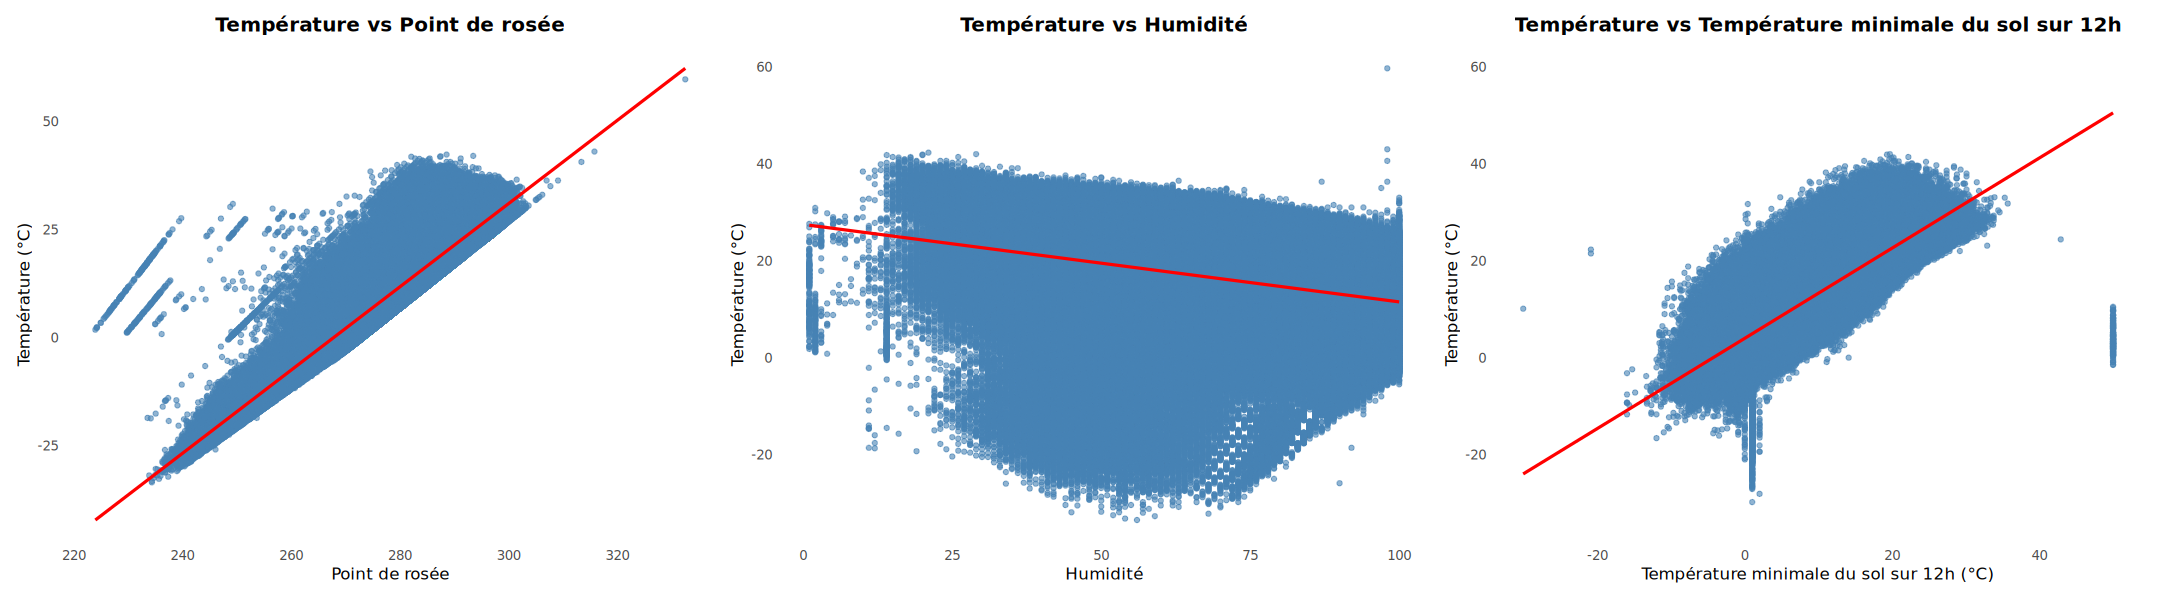

In [23]:
#Représentation graphique des nuages de points avec les droites de régression
plot1 <- ggplot(data_final, aes(x = Point.de.rosée, y = Température...C.)) +
  geom_point(color = "steelblue", alpha = 0.6, size = 1.2) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(title = "Température vs Point de rosée",
       x = "Point de rosée",
       y = "Température (°C)") +
  theme_minimal(base_size = 10) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
    panel.grid = element_blank()
  )

plot2 <- ggplot(data_final, aes(x = Humidité, y = Température...C.)) +
  geom_point(color = "steelblue", alpha = 0.6, size = 1.2) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(title = "Température vs Humidité",
       x = "Humidité",
       y = "Température (°C)") +
  theme_minimal(base_size = 10) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
    panel.grid = element_blank()
  )   

plot3 <- ggplot(data_final, aes(x = Température.minimale.du.sol.sur.12.heures..en..C., y = Température...C.)) +
  geom_point(color = "steelblue", alpha = 0.6, size = 1.2) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(title = "Température vs Température minimale du sol sur 12h",
       x = "Température minimale du sol sur 12h (°C)",
       y = "Température (°C)") +
  theme_minimal(base_size = 10) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
    panel.grid = element_blank()
  )      
# Afficher les plots côte à côte
options(repr.plot.width = 18, repr.plot.height = 5)
plot1 + plot2 + plot3 + plot_layout(ncol = 3)
# Réinitialiser la taille du canevas
options(repr.plot.width = 7, repr.plot.height = 5)

Conclusions : 
- La régression de la température en fonction de l'humidité est mauvaise (R² < 0.1).
- La régression de la température en fonction de la température minimale du sol sur 12h est meilleure (R² = 0.67) mais peu intéressante physiquement. Il est clair que ces deux variables sont liées mais les variations de la température du sol sont plus faible que celle de l'air.
- Enfin, la régression de la température en fonction du point de rosée est bonne (R² = 0.8) mais pas suffisante pour établir une relation linéaire directe entre ces deux variables. 

Ces trois variables ont une influence sur la température mais n'expliques pas à elles seules la température. On va donc effectuer une régression linéaire multiple.

### II. Régression linéaire multiple

In [24]:
#Régression linéaire multiple de la temmpérature en fonction du point de rosée et de l'humidité
lm_multiple <- lm(Température...C. ~ Point.de.rosée + Humidité, data = data_final)
cat("Régression Température ~ Point de rosée + Humidité :\n")
cat(sprintf("Équation : Température = %.3f + %.3f * Point de rosée\n + %.3f * Humidité", coef(lm_multiple)[1], coef(lm_multiple)[2], coef(lm_multiple)[3]))

Régression Température ~ Point de rosée + Humidité :
Équation : Température = -259.207 + 1.031 * Point de rosée
 + -0.238 * Humidité

In [25]:
#Calcul du R² pour le modèle multiple
r2_multiple <- summary(lm_multiple)$r.squared
cat(sprintf("\nR² pour Température ~ Point de rosée + Humidité : %.4f\n", r2_multiple))


R² pour Température ~ Point de rosée + Humidité : 0.9902


Conclusion : La régression linéaire multiple donne de bien meilleur résultats (R² = 0.99). L'équation : -259.207 +1.031 * Point de rosée -0.238 * Humidité
semble être un bon modèle de la température. 

### III. Etude de corrélation

Déjà fait en partie 1 avec la matrice de corrélation sous forme de heat map.

On retrouve le fait que la température est fortement corrélée avec le point de rosée et la température minimal du sol (0.82), et également dans une moindre mesure avec l'humidité (-0.53). 

## Partie 5 : ACP et PLS

### ACP

Résumé de l'ACP :
Importance of components:
                          PC1    PC2    PC3    PC4    PC5    PC6     PC7
Standard deviation     1.4491 1.2033 1.0821 1.0230 0.9230 0.8859 0.77038
Proportion of Variance 0.2625 0.1810 0.1464 0.1308 0.1065 0.0981 0.07419
Cumulative Proportion  0.2625 0.4435 0.5899 0.7207 0.8272 0.9253 0.99945
                           PC8
Standard deviation     0.06611
Proportion of Variance 0.00055
Cumulative Proportion  1.00000


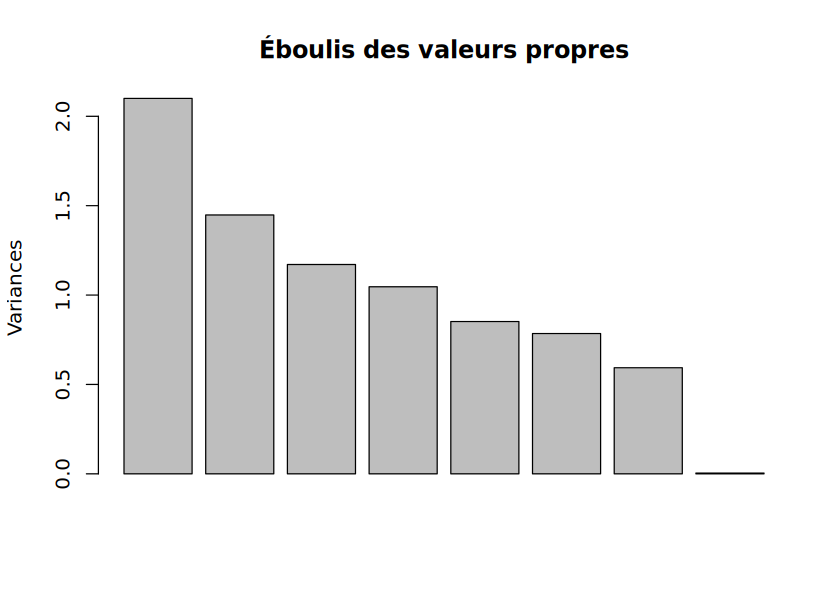

In [26]:
# Sélection des variables numériques pertinentes
data_num <- data_final %>%
  select(Pression.au.niveau.mer,
         Variation.de.pression.en.3.heures,
         Direction.du.vent.moyen.10.mn,
         Vitesse.du.vent.moyen.10.mn,
         Point.de.rosée,
         Humidité,
         Altitude,
         Température...C.)

# Remplacer les valeurs manquantes par la moyenne de la colonne pour l'ACP (méthode simple)
data_num <- na.omit(data_num)

# Effectuer l'ACP
acp_result <- prcomp(data_num, scale. = TRUE)

# Résumé de l'ACP
cat("Résumé de l'ACP :\n")
print(summary(acp_result))

# Visualisation de l'éboulis des valeurs propres
plot(acp_result, main = "Éboulis des valeurs propres")

In [27]:
# Analyse de la contribution des variables aux premières composantes
# Pourcentage de variance expliquée par chaque composante
var_expl <- acp_result$sdev^2 / sum(acp_result$sdev^2) * 100
cat("\nPourcentage de variance expliquée par chaque composante :\n")
print(round(var_expl, 2))


Pourcentage de variance expliquée par chaque composante :
[1] 26.25 18.10 14.64 13.08 10.65  9.81  7.42  0.05


On remarque que la majorité de la variance est comprise dans les trois premières composantes principales. Ainsi, il est difficile de définir de bonnes composantes principales pour un plot en 2D.

Affichage des stations en fonction des composantes principales

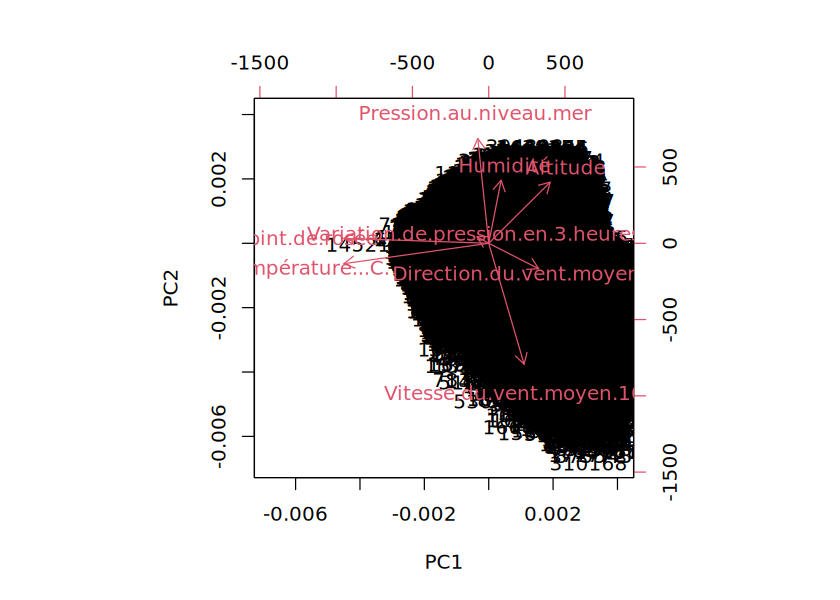

In [28]:
biplot(acp_result)
# Réinitialiser la taille du canevas
options(repr.plot.width = 30, repr.plot.height = 30)

### PLS

In [29]:
# PLS : Prédiction de la température
pls_model <- plsr(Température...C. ~ ., data = data_num, validation = "CV")

# Résumé du modèle
summary(pls_model)

Data: 	X dimension: 1595442 7 
	Y dimension: 1595442 1
Fit method: kernelpls
Number of components considered: 7

VALIDATION: RMSEP
Cross-validated using 10 random segments.
       (Intercept)  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps
CV           9.263    9.228    8.907    8.712    6.733    4.975   0.8951
adjCV        9.263    9.229    8.907    8.712    6.734    4.975   0.8951
       7 comps
CV      0.8904
adjCV   0.8904

TRAINING: % variance explained
                  1 comps  2 comps  3 comps  4 comps  5 comps  6 comps  7 comps
X                 89.6764   96.914    98.15    98.94    99.98   100.00   100.00
Température...C.   0.7493    7.542    11.54    47.16    71.15    99.07    99.08


On remarque que les premières composantes expliquent surtout la structure de X (comp 1 : 91%) mais il faut attendre la 6ᵉ composante pour capturer quasiment toute la variance de Y (Température) avec 99%. On peut donc conclure que la température est liée à plusieurs sources de variation combinées dans la data_mun (non capturée par un seul axe principal).

R² du modèle PLS avec 7 composantes : 0.991 

Loadings:
                                  Comp 1 Comp 2 Comp 3 Comp 4 Comp 5 Comp 6
Pression.au.niveau.mer             0.52  -0.86                             
Variation.de.pression.en.3.heures                       0.22  -0.97        
Direction.du.vent.moyen.10.mn     -0.38  -0.22  -0.31   0.83   0.17        
Vitesse.du.vent.moyen.10.mn                                                
Point.de.rosée                     0.19   0.12   0.69   0.37   0.10   0.56 
Humidité                          -0.12         -0.50  -0.24          0.82 
Altitude                          -0.73  -0.44   0.42  -0.26  -0.15        
                                  Comp 7
Pression.au.niveau.mer                  
Variation.de.pression.en.3.heures       
Direction.du.vent.moyen.10.mn           
Vitesse.du.vent.moyen.10.mn        1.00 
Point.de.rosée                          
Humidité                                
Altitude                                

       

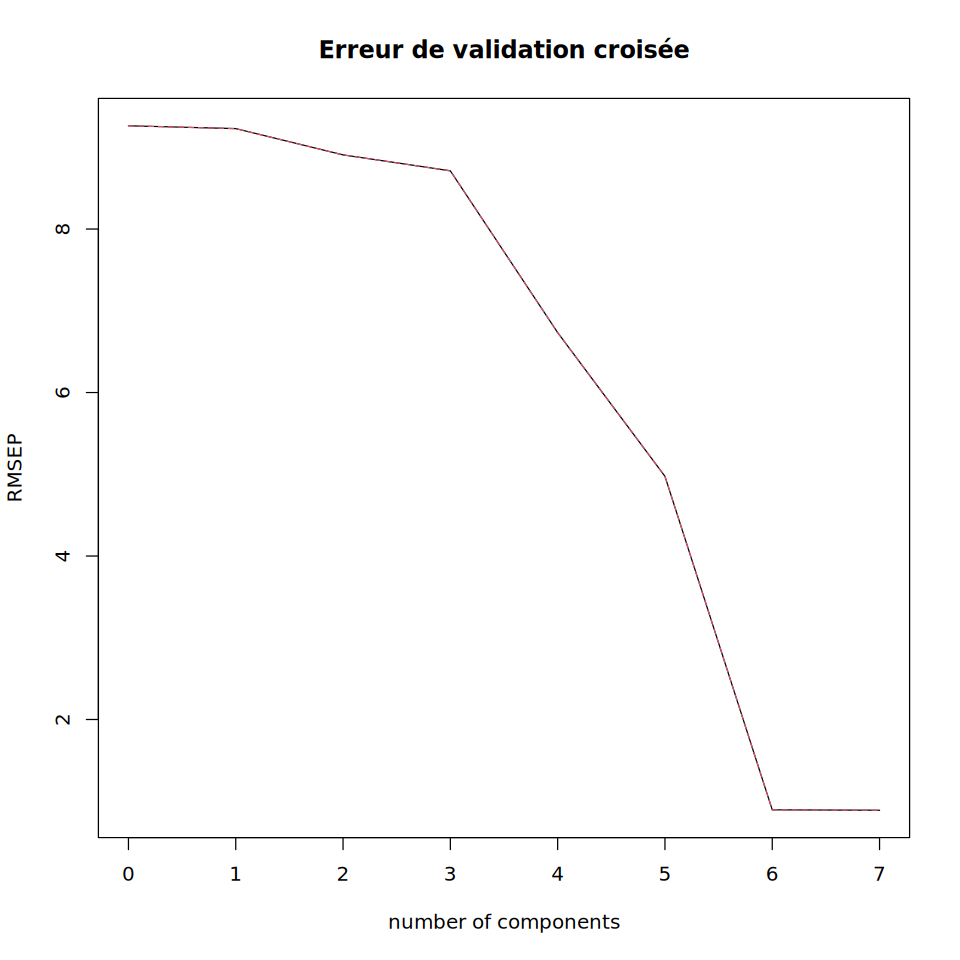

In [30]:
# Réinitialiser la taille du canevas
options(repr.plot.width = 8, repr.plot.height = 8)

# Choix du nombre optimal de composantes avec la validation plot
validationplot(pls_model, val.type = "RMSEP", main = "Erreur de validation croisée")

# Calcul du R² global pour nombre optimal de composantes
ncomp_opt <- which.min(RMSEP(pls_model)$val[estimate = "adjCV", , ]) - 1
Y_pred <- predict(pls_model, ncomp = ncomp_opt)
Y <- data_num$Température...C.
R2 <- cor(Y, Y_pred)^2
cat("R² du modèle PLS avec", ncomp_opt, "composantes :", round(R2, 3), "\n")

# Calcul poids des variables dans le modèle PLS
pls_loadings <- pls_model$loading.weights
print(round(pls_loadings, 2))

R2=99% donc les composantes météorologiques représentent de manière excellente la Température

Analyse des composantes
Comp 1: La Température augmente avec la pression et diminue avec l'altitude
Comp 2: Les zones de basses pression peuvent induire des températures plus basses
Comp 3 : Lorsque le point de rosée augmente, la température augmente : air humide => température plus douces
Comp 4 : Influence des changements da masse d'air
Comp 5: Changement de pression très rapides (phénomènes transitoires) : peut être des fronts froids/chauds
Comp 6:Comme le point 3, plus l'air est humide et plus la température augmente
Comp 7: La vitesse du vent contribue peu à la température mais a tout de même son rôle à jouer
Donc la température est surtout déterminée par :
- le niveau de pression (corrélation directe),
- l’altitude (effet inverse),
- le point de rosée et l’humidité (effet positif).

## Partie 6 : Une méthode de clustering

L’objectif est de regrouper les stations météorologiques en fonction de leurs caractéristiques observées afin de mettre en évidence des profils climatiques similaires.
La question centrale est : Quelles variables (ou combinaisons de variables) structurent les regroupements entre stations ?

On commence par sélectionner quelques variables météorologiques jugées pertinentes (comme la température, l’humidité ou la pression) afin de résumer le profil de chaque station. On calcule ensuite des valeurs moyennes pour chaque station afin de rendre les données comparables entre elles. Enfin, on nettoie les éventuelles valeurs manquantes pour obtenir un tableau clair et complet, qui servira de base au regroupement des stations.

In [31]:
vars_clustering <- c("Température...C.",
                     "Température.minimale.du.sol.sur.12.heures..en..C.",
                     "Humidité",
                     "Point.de.rosée",
                     "Pression.station")

data_cluster <- data_final %>%
  group_by(ID.OMM.station) %>%
  summarise(across(all_of(vars_clustering), \(x) mean(x, na.rm = TRUE))) %>%
  ungroup() %>%
  as.data.frame()

row.names(data_cluster) <- data_cluster$ID.OMM.station
data_cluster <- data_cluster[,-1]

data_cluster <- data_cluster %>%
  mutate(across(where(is.numeric), 
                ~ ifelse(is.na(.) | is.nan(.) | is.infinite(.), mean(., na.rm = TRUE), .)))

data_cluster



,Température...C.,Température.minimale.du.sol.sur.12.heures..en..C.,Humidité,Point.de.rosée,Pression.station
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
7005,11.649503,8.679325,80.33446,281.1676,100782.41
7015,11.987338,8.357385,77.25565,280.7682,101063.27
7020,12.776474,10.215945,81.67951,282.7169,101491.64
7027,11.912485,9.336582,81.25286,281.6506,100878.50
7037,11.492857,9.498509,79.98217,280.8667,99840.77
7072,11.686203,7.779000,78.50429,280.7028,100556.67
7110,12.093257,8.526394,83.78457,282.3460,100525.30
7117,12.605806,10.215945,81.46689,282.5227,100964.77
7130,12.696035,9.319131,79.54137,281.9281,101276.88


Ensuite, on met toutes les variables sur la même échelle pour éviter que l’une d’elles domine les autres. On calcule les distances entre stations et on applique un clustering hiérarchique (méthode de Ward) pour regrouper les stations les plus proches. Le dendrogramme obtenu permet de visualiser la hiérarchie des regroupements, et on choisit un nombre de groupes (ici 5) en traçant des séparations dans l’arbre.

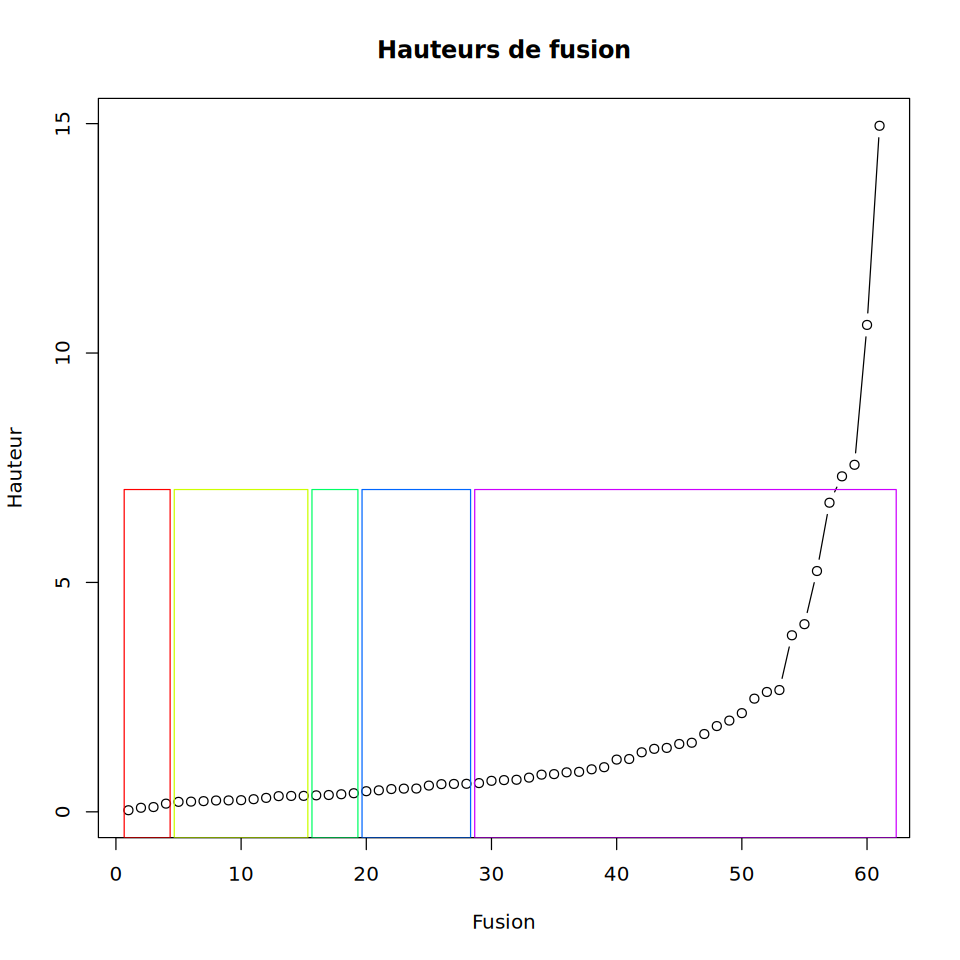

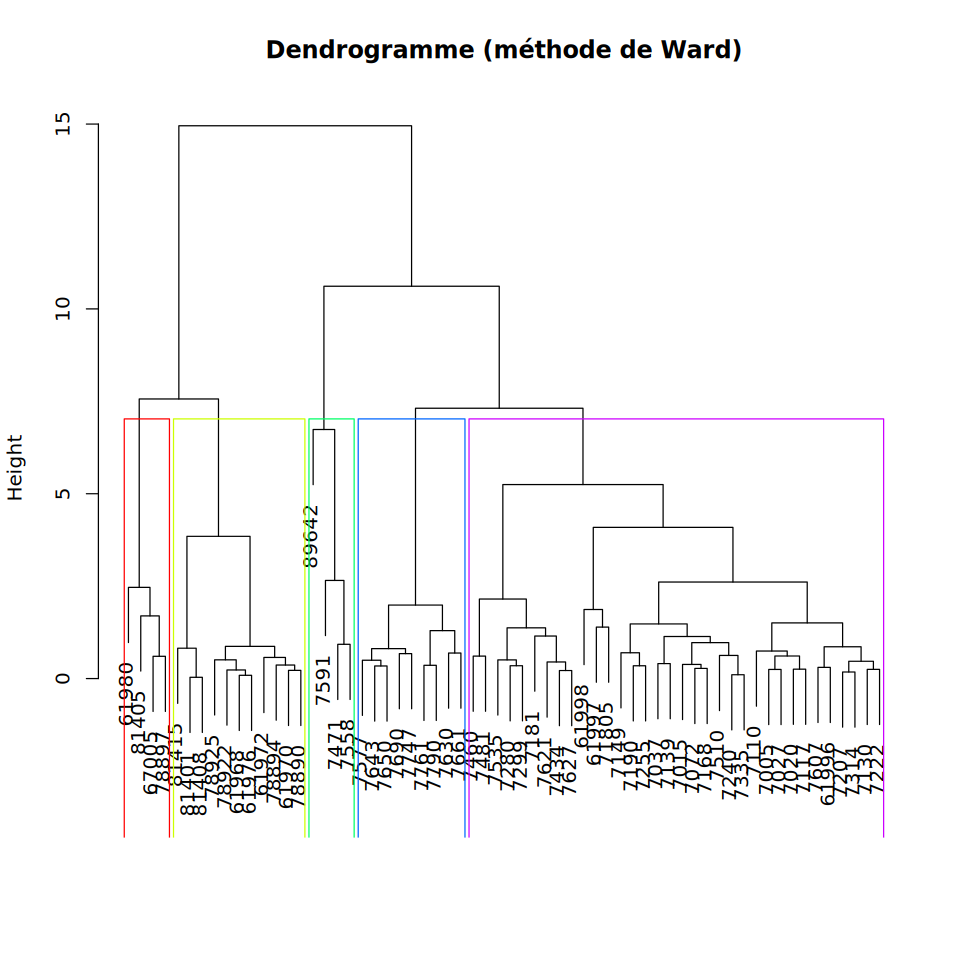

In [32]:
par(bg="white")
data_scaled <- scale(data_cluster)
dist_mat <- dist(data_scaled)
cah <- hclust(dist_mat, method = "ward.D2")

plot(cah$height, type="b", main="Hauteurs de fusion", ylab="Hauteur", xlab="Fusion")
k <- 5
gr <- cutree(cah, k)
rect.hclust(cah, k=k, border=rainbow(k))

plot(cah,, main="Dendrogramme (méthode de Ward)", xlab="", sub="")
rect.hclust(cah, k = k, border =rainbow(k))

On calcule le profil moyen de chaque groupe de stations, ce qu’on appelle le barycentre d’un cluster. Cela permet de résumer chaque regroupement par ses caractéristiques météorologiques typiques et de comparer facilement les profils moyens des différents clusters.

In [33]:
# calcul des barycentres : aggregate -> data.frame -> matrice (sans la colonne groupe)
centres_df <- aggregate(data_cluster, by = list(cluster = gr), FUN = mean)
# centres_df a une colonne 'cluster' puis 5 colonnes de moyennes
centres_mat <- as.matrix(centres_df[ , -1, drop = FALSE])  # matrice nrow = k, ncol = 5

On utilise les profils moyens des clusters calculés précédemment pour lancer un K-means stable, qui attribue chaque station à un groupe de façon définitive. Cela permet de confirmer et de stabiliser le regroupement des stations autour de profils représentatifs.

In [34]:
km <- kmeans(data_cluster, centers = centres_mat)
cat("Groupes des individus pour le K-means stable :\n")
print(km$cluster)

Groupes des individus pour le K-means stable :
 7005  7015  7020  7027  7037  7072  7110  7117  7130  7139  7149  7168  7181 
    4     5     5     4     3     4     4     5     5     3     4     4     1 
 7190  7207  7222  7240  7255  7280  7299  7314  7335  7434  7460  7471  7481 
    3     5     5     4     3     3     1     5     4     1     1     2     3 
 7510  7535  7558  7577  7591  7607  7621  7627  7630  7643  7650  7661  7690 
    5     3     2     4     2     5     1     1     3     5     5     3     5 
 7747  7761  7790 61968 61970 61972 61976 61980 61996 61997 61998 67005 71805 
    5     5     5     5     5     5     5     5     5     3     3     5     5 
78890 78894 78897 78922 78925 81401 81405 81408 81415 89642 
    5     5     5     5     5     5     5     5     3     1 


On compare les résultats du clustering hiérarchique et du K-means en construisant une table de contingence. Cela permet de voir dans quelle mesure les deux méthodes assignent les mêmes stations aux mêmes groupes et d’évaluer la cohérence des clusters.

In [35]:
tab <- table(CAH = gr, KMEANS = km$cluster)
print("Table de contingence CAH vs KMeans :")
print(tab)

[1] "Table de contingence CAH vs KMeans :"


   KMEANS
CAH  1  2  3  4  5
  1  6  0  9  8 11
  2  1  3  0  0  0
  3  0  0  2  1  6
  4  0  0  1  0 10
  5  0  0  0  0  4


La table de contingence montre une correspondance partielle entre la CAH et K-means. Certains groupes sont très cohérents, comme CAH 2 avec le cluster 2, ou encore CAH 4 et 5 qui se retrouvent presque entièrement dans le cluster 5 de K-means. En revanche, le groupe CAH 1 est éclaté sur plusieurs clusters, traduisant une divergence entre les deux méthodes. Globalement, K-means a tendance à regrouper plusieurs classes de la CAH dans un même cluster, ce qui montre une structure similaire mais moins fine.

On réalise une analyse en composantes principales (ACP) pour réduire les variables météo à deux dimensions principales, ce qui permet de visualiser les différences entre stations. Chaque station est ensuite affichée sur le graphique, colorée selon son groupe issu du clustering hiérarchique. Cela permet de voir si les clusters sont bien séparés dans l’espace des profils thermiques.

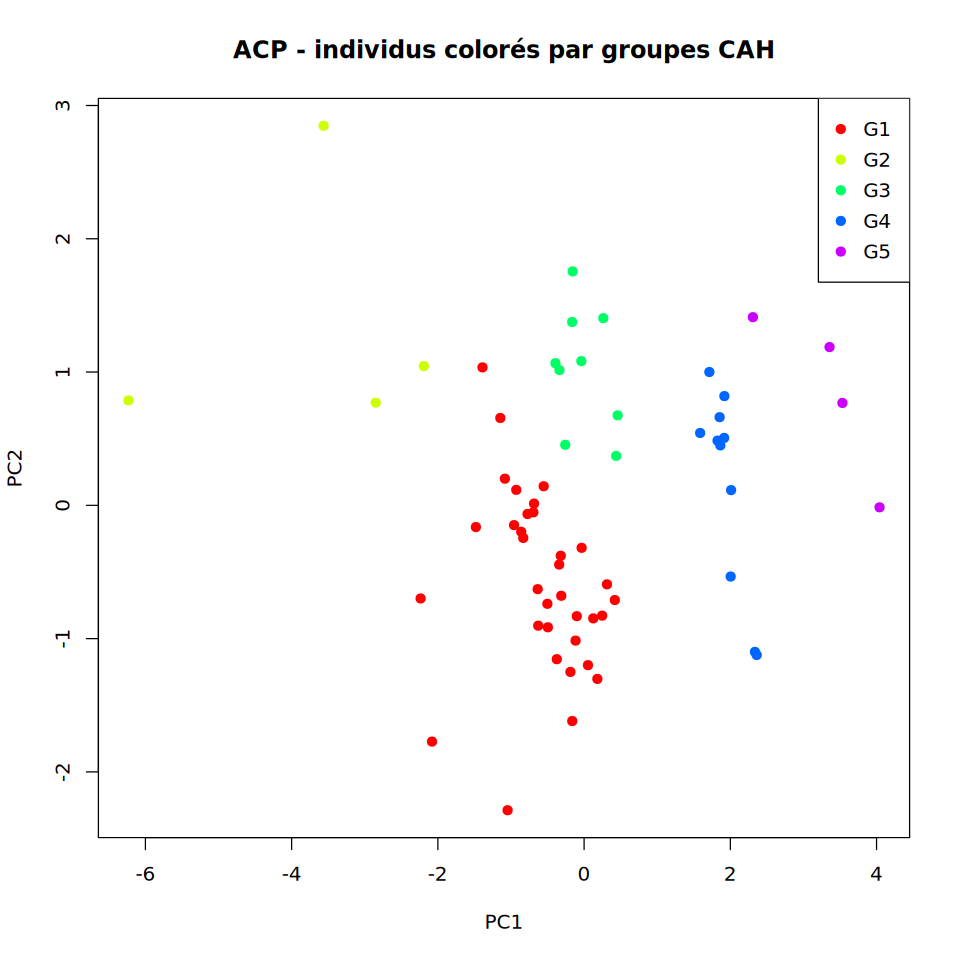

In [36]:
par(bg="white")
acp <- prcomp(data_cluster, scale.=TRUE)

coords <- acp$x[,1:2]

# Tracé ACP avec couleurs par groupe
cols <- rainbow(k)
plot(coords, col=cols[gr], pch=19,
     xlab="PC1", ylab="PC2",
     main="ACP - individus colorés par groupes CAH")
legend("topright", legend=paste0("G", 1:k), col=cols, pch=19)

On compare la répartition de la température entre les différents groupes de stations. Le boxplot montre la variation et la médiane de la température dans chaque cluster, ce qui permet de visualiser les différences de profils thermiques entre les groupes.

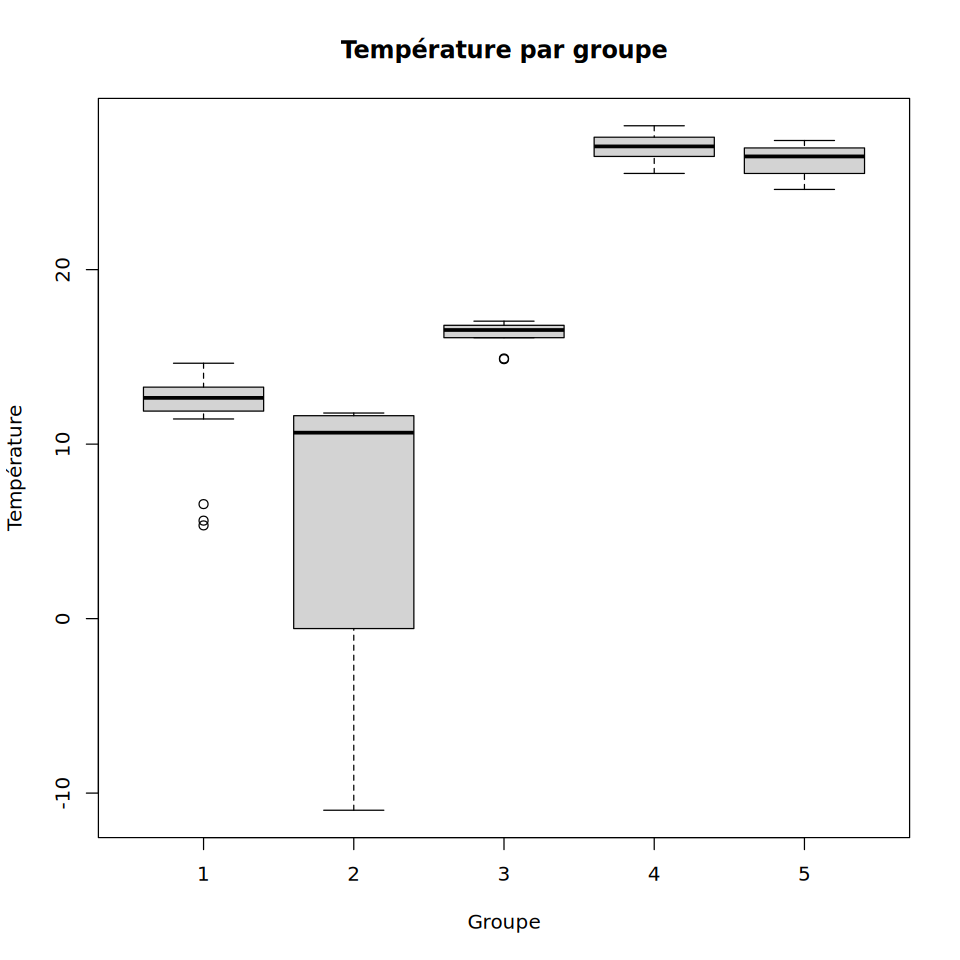

In [37]:
par(bg="white")
boxplot(data_cluster$Température...C. ~ gr, main="Température par groupe", xlab="Groupe", ylab="Température")

Nous allons maintenant essayer de représenter notre clustering de stations sur la carte de la France, pour voir si les groupes choisis peuvent s'expliquer à partir de la localisation des stations. (Cela parait logique puisque les données sur lesquelles nous avons concentré notre étude dépendent de la localisation)

l’idée est de préparer les données géographiques des stations. On extrait uniquement l’identifiant, la latitude et la longitude, puis on supprime les doublons pour ne garder qu’une ligne par station. Ensuite, on affiche les groupes issus du clustering (gr) et les coordonnées des stations (data_geo) afin de pouvoir ensuite les croiser et visualiser leur répartition géographique.

In [38]:
data_geo <- data_final[, c("ID.OMM.station", "Latitude", "Longitude")]
data_geo <- data_geo %>%
  distinct(ID.OMM.station, .keep_all = TRUE)
print(gr)
print(data_geo)

 7005  7015  7020  7027  7037  7072  7110  7117  7130  7139  7149  7168  7181 
    1     1     1     1     1     1     1     1     1     1     1     1     1 
 7190  7207  7222  7240  7255  7280  7299  7314  7335  7434  7460  7471  7481 
    1     1     1     1     1     1     1     1     1     1     1     2     1 
 7510  7535  7558  7577  7591  7607  7621  7627  7630  7643  7650  7661  7690 
    1     1     2     3     2     1     1     1     3     3     3     3     3 
 7747  7761  7790 61968 61970 61972 61976 61980 61996 61997 61998 67005 71805 
    3     3     3     4     4     4     4     5     1     1     1     5     1 
78890 78894 78897 78922 78925 81401 81405 81408 81415 89642 
    4     4     5     4     4     4     5     4     4     2 
   ID.OMM.station   Latitude  Longitude
1            7690  43.648833   7.209000
2           61998 -49.352333  70.243333
3           78925  14.595333 -60.995667
4            7149  48.716833   2.384333
5            7139  48.445500   0.110167
6     

On associe ensuite les résultats du clustering aux coordonnées des stations. On commence par transformer le vecteur de groupes en un tableau avec l’ID de chaque station et son cluster. Puis on fait une jointure avec les données géographiques pour obtenir un seul tableau qui contient à la fois l’identifiant, la position (latitude et longitude) et le cluster de chaque station. Ce tableau complet servira ensuite pour l’analyse et la visualisation sur carte.

In [39]:
# Créer un dataframe à partir du vecteur de clusters
clusters_df <- data.frame(
  ID.OMM.station = as.numeric(names(gr)),
  cluster = as.factor(gr)
)

# Faire la jointure avec les coordonnées
data_geo_cluster <- clusters_df %>%
  inner_join(data_geo, by = "ID.OMM.station")

# Résultat
print(data_geo_cluster)


   ID.OMM.station cluster   Latitude  Longitude
1            7005       1  50.136000   1.834000
2            7015       1  50.570000   3.097500
3            7020       1  49.725167  -1.939833
4            7027       1  49.180000  -0.456167
5            7037       1  49.383000   1.181667
6            7072       1  49.209667   4.155333
7            7110       1  48.444167  -4.412000
8            7117       1  48.825833  -3.473167
9            7130       1  48.068833  -1.734000
10           7139       1  48.445500   0.110167
11           7149       1  48.716833   2.384333
12           7168       1  48.324667   4.020000
13           7181       1  48.581000   5.959833
14           7190       1  48.549500   7.640333
15           7207       1  47.294333  -3.218333
16           7222       1  47.150000  -1.608833
17           7240       1  47.444500   0.727333
18           7255       1  47.059167   2.359833
19           7280       1  47.267833   5.088333
20           7299       1  47.614333   7

On peut désormais tracer la carte qui nous intéresse :

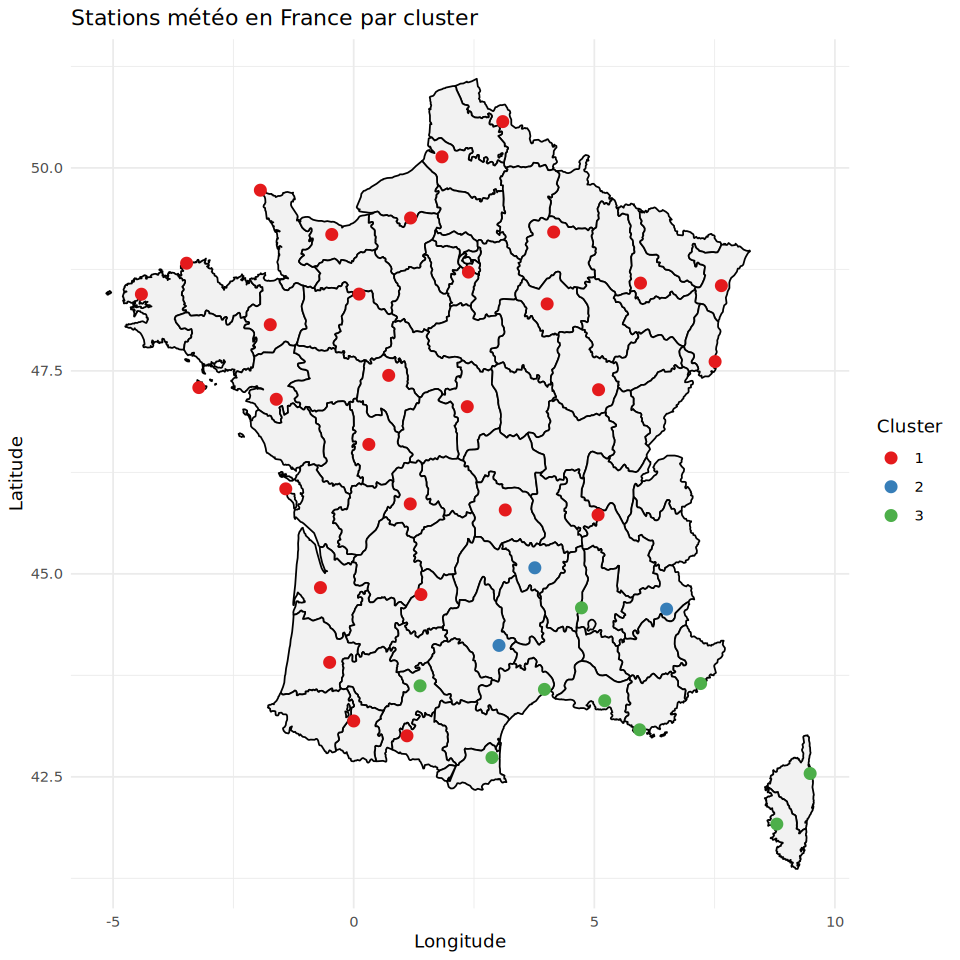

In [40]:
# Filtrer seulement les stations en France (optionnel si ton dataframe contient aussi l'étranger)
stations_fr <- data_geo_cluster %>%
  filter(Latitude > 40 & Latitude < 52, Longitude > -6 & Longitude < 10)

# Carte de la France
france_map <- map_data("france")

# Tracé
ggplot() +
  geom_polygon(data = france_map, aes(x = long, y = lat, group = group),
               fill = "gray95", color = "black") +
  geom_point(data = stations_fr, aes(x = Longitude, y = Latitude, color = cluster),
             size = 3) +
  scale_color_brewer(palette = "Set1") +
  theme_minimal() +
  labs(title = "Stations météo en France par cluster",
       x = "Longitude", y = "Latitude", color = "Cluster")


La carte obtenue met en évidence une forte concentration de stations regroupées dans le même cluster (rouge), couvrant la quasi-totalité du territoire, en particulier le nord et le centre de la France. Cela traduit une certaine homogénéité dans les données, mais cela peut aussi indiquer que l’algorithme a privilégié un regroupement majoritaire, au détriment d’une différenciation plus fine. À l’inverse, les stations situées près du littoral méditerranéen apparaissent davantage dispersées entre les clusters vert et bleu. Cela peut refléter la spécificité du climat méditerranéen, marqué par des contrastes plus forts (chaleur estivale, sécheresse, influence maritime).

Le clustering met en évidence une structuration géographique tout de même cohérente :

Nord de la France → homogénéité climatique (forte concentration d’un seul cluster).

Sud/Méditerranée → diversité climatique (plusieurs clusters coexistent).

Cela confirme que les regroupements identifiés par l’algorithme traduisent bien des différences régionales dans les régimes météorologiques.